 Code for Testing 12 Attention Layers

 ## 1. Experiment Setup

 **Import Modules**

In [ ]:
import sys
import os 

project_root = os.path.abspath(os.path.join(os.getcwd(), './src'))
if project_root not in sys.path:
    sys.path.append(project_root)
    
project_root = os.path.abspath(os.path.join(os.getcwd(), '../src'))
if project_root not in sys.path:
    sys.path.append(project_root)

import numpy as np
import math
import torch
from transformers import BertForNextSentencePrediction
import matplotlib.pyplot as plt

import thor
from thor import CkksEngine, ThorDataEncryptor, ThorLinearEvaluator
from thor.bert import ThorBert, ThorBertFF, ThorBertPooler, ThorBertClassifier

 ### 0-1. GPU memory queries

In [ ]:
import subprocess
import gc
from pathlib import Path

def gpu_memory():
    output = subprocess.check_output(
        [
            "nvidia-smi",
            "--query-gpu=memory.used",
            "--format=csv,noheader,nounits",
        ],
        text=True,
    )
    return [int(x.strip()) for x in output.splitlines()]

def print_gpu_memory(label):
    print(f"[GPU] {label}: {gpu_memory()} MiB", flush=True)

 ### 0-2. Remove warnings

In [ ]:
import logging
loggers = [logging.getLogger(name) for name in logging.root.manager.loggerDict]
for logger in loggers:
    if "transformers" in logger.name.lower():
        logger.setLevel(logging.ERROR)

 ### 1-1. Initiate CKKS Engine

 **Choose GPU**

In [ ]:
devices = [0, 1, 2, 3]
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cu_device = devices[1]
with torch.cuda.device(cu_device):
    torch.cuda.empty_cache()
    print(torch.cuda.memory_allocated(cu_device) /1024**3)

0.0


In [ ]:
engine = CkksEngine(
    mode="gpu",
    device_id=cu_device,
    use_bootstrap_to_17_levels=True,
)
print_gpu_memory("after engine init")

[GPU] after engine init: [11286, 487, 8099, 4] MiB


 **Load DesiloFHE Keys**

In [ ]:
key_dir = Path("./keys/desilofhesplit17")
key_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
if (key_dir / "secret.key").exists():
    sk = engine.read_secret_key(key_dir / "secret.key")
    pk = engine.read_public_key(key_dir / "public.key")
    evk = engine.read_relinearization_key(key_dir / "relinearization.key")
    gk = engine.read_rotation_key(key_dir / "rotation.key")
    conjk = engine.read_conjugation_key(key_dir / "conjugation.key")
    bsk = engine.read_bootstrap_key(key_dir / "bootstrap.key")
else:
    sk = engine.create_secret_key()
    pk = engine.create_public_key(sk)
    evk = engine.create_relinearization_key(sk)
    gk = engine.create_rotation_key(sk)
    conjk = engine.create_conjugation_key(sk)
    bsk = engine.create_bootstrap_key(sk)
    engine.write_secret_key(sk, key_dir / "secret.key")
    engine.write_public_key(pk, key_dir / "public.key")
    engine.write_relinearization_key(evk, key_dir / "relinearization.key")
    engine.write_rotation_key(gk, key_dir / "rotation.key")
    engine.write_conjugation_key(conjk, key_dir / "conjugation.key")
    engine.write_bootstrap_key(bsk, key_dir / "bootstrap.key")
engine.add_pk(pk)
engine.add_evk(evk)
engine.add_gk(gk)
engine.add_conj_key(conjk)
engine.add_bs_key(bsk)
print_gpu_memory("after key loading")

[GPU] after key loading: [11286, 22571, 8099, 4] MiB


 ### 1-2. Load and Encrypt Data

 **Set Datatset Type and Target Data Index**

In [ ]:
dataset_type = 'mrpc'
target_idx = 0

 **Initiate DataEncryptor and DataLoader**

In [ ]:
dataset = f'./datasets/{dataset_type}'

data_encryptor = ThorDataEncryptor(dataset_type, dataset,
                                   embedding_model=BertForNextSentencePrediction.from_pretrained('bert-base-uncased').bert.embeddings, 
                                   ckks_engine=engine, test=False)
data_loader = data_encryptor.eval_dataloader

Loading dataset from disk


Parameter 'function'=<bound method ThorDataEncryptor._tokenize of <thor.data.ThorDataEncryptor object at 0x777a06577a60>> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


Map:   0%|          | 0/408 [00:00<?, ? examples/s]

 **Encrypt Data as "x"**

In [ ]:
def encode_attention_mask(engine, attention_mask:np.ndarray, level:int=15) -> np.ndarray:
    """
    Return an array of size (8,) which contains 8 plaintexts. 
    """
    if attention_mask.shape != (128,):
        raise ValueError("Shape of attention mask should be (128,)")
    n_tokens = np.count_nonzero(attention_mask)
    attention_mask = np.full((8,), None, dtype=object)
    for i in range(8):
        msg = np.zeros((2**15,), dtype=float)
        for j in range(16):
            temp = j *(2**11)
            diag_index = i * 16 + j
            for t in range(128):
                col_index = (diag_index + t) % 128
                is_token = 1 if col_index < n_tokens else 0
                for head in range(12):
                    msg[temp + t*16 + head] = is_token
        attention_mask[i] = engine.encode(msg, level)
    return attention_mask


# # %% 
# # Test error fix of batch raising ValueError
# batch = next(iter(data_encryptor.eval_dataloader))
# print(batch)

In [ ]:
idx = 0
for batch in data_loader:
    if idx < target_idx:
        idx += 1
        continue
    if idx == target_idx:
        data= {k: v for k, v in batch.items() if k in ['input_ids', 'token_type_ids']}
        embedding = data_encryptor.embed_data(data)
        x = data_encryptor.encrypt_embedding(embedding, pk, level=9)
        attention_mask = batch['attention_mask']
        thor_attention_mask = data_encryptor.encode_attention_mask(attention_mask.cpu().numpy().squeeze().T, level=13)
        break

 ### 1-3. Load and Run plain(non HE) Model for Comparison

 **Load and Run Plain Model**

In [ ]:
model_plain  = thor.utils.load_model(dataset_type, f'./finetuned_models/{dataset_type}/model.safetensors')

model_plain.eval()
cpu_device = torch.device("cpu")
model_plain.to(cpu_device)

print_gpu_memory("after loading finetuned model")

idx = 0
for batch in data_loader:
    print(idx, target_idx)
    if idx < target_idx:
        idx += 1
        continue
    elif idx == target_idx:
        batch = {k: v.to(cpu_device) if torch.is_tensor(v) else v for k, v in batch.items()}
        with torch.no_grad():
            outputs = model_plain(**batch)
        break

print_gpu_memory("after plain model")

def get_nonlinear_in_out(hidden_states, layer_idx):
    with torch.no_grad():
        bert_layer_m = model_plain.bert.encoder.layer[layer_idx] 
        attention_m = bert_layer_m.attention.self
        bert_output_m = model_plain.bert.encoder.layer[layer_idx].attention.output

        q = attention_m.transpose_for_scores(attention_m.query(hidden_states))
        k = attention_m.transpose_for_scores(attention_m.key(hidden_states))
        v = attention_m.transpose_for_scores(attention_m.value(hidden_states))
        attention_scores = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(attention_m.attention_head_size)
        extended_att_mask = model_plain.get_extended_attention_mask(
                        attention_mask, 768
                    ).to(cpu_device)
        sfmtx_in = attention_scores+extended_att_mask
        att_probs_m = torch.nn.functional.softmax(sfmtx_in, dim=-1)
        sfmtx_out = att_probs_m
        att_context_m = torch.matmul(att_probs_m, v)
        context_layer = att_context_m.permute(0, 2, 1, 3).contiguous()
        new_context_layer_shape = context_layer.size()[:-2] + (attention_m.all_head_size,)
        context_layer = context_layer.view(new_context_layer_shape)
        dense_output_m = bert_output_m.dense(context_layer)
        ln1_in = dense_output_m + hidden_states
        ln1_out = bert_output_m.LayerNorm(ln1_in)
        gelu_in = bert_layer_m.intermediate.dense(ln1_out)
        gelu_out = bert_layer_m.intermediate.intermediate_act_fn(gelu_in)
        dense2_out = bert_layer_m.output.dense(gelu_out)
        ln2_in = dense2_out + ln1_out
        ln2_out = bert_layer_m.output.LayerNorm(ln2_in)
        pooler_m = model_plain.bert.pooler
        pooler_dense_output = pooler_m.dense(ln2_out[:, 0])
        # print(ln2_out[:, 0].shape)
        pooler_output = pooler_m.activation(pooler_dense_output)

    return (
        hidden_states.cpu().numpy().squeeze(),
        q.cpu().numpy().squeeze(),
        sfmtx_in.cpu().numpy().squeeze(),
        sfmtx_out.cpu().numpy().squeeze(),
        att_context_m.cpu().numpy().squeeze(),
        ln1_in.cpu().numpy().squeeze(),
        ln1_out.cpu().numpy().squeeze(),
        gelu_in.cpu().numpy().squeeze(),
        gelu_out.cpu().numpy().squeeze(),
        dense2_out.cpu().numpy().squeeze(),
        ln2_in.cpu().numpy().squeeze(),
        ln2_out.cpu().numpy().squeeze(),
        pooler_dense_output.cpu().numpy().squeeze(),
        pooler_output.cpu().numpy().squeeze()
        )
    
hidden_states = []
qs= []
ks = []
sftmx_ins = []
sftmx_outs = []
att_contexts = []
ln1_ins = []
ln1_outs = []
gelu_ins = []
gelu_outs = []
dense2_outs = []
ln2_ins = []
ln2_outs = []
for layer in range(12):
    hidden_state, q, sftmx_in, sftmx_out, att_context, ln1_in, ln1_out, gelu_in, gelu_out, dense2_out, ln2_in, ln2_out, pooler_dense_out, pooler_out = get_nonlinear_in_out(outputs.hidden_states[layer], layer)
    hidden_states.append(hidden_state)
    qs.append(q)
    sftmx_ins.append(sftmx_in)
    sftmx_outs.append(sftmx_out)
    att_contexts.append(att_context)
    ln1_ins.append(ln1_in)
    ln1_outs.append(ln1_out)
    gelu_ins.append(gelu_in)
    gelu_outs.append(gelu_out)
    dense2_outs.append(dense2_out)
    ln2_ins.append(ln2_in)
    ln2_outs.append(ln2_out)

Model loaded for mrpc
[GPU] after loading finetuned model: [11286, 22623, 8099, 4] MiB
0 0
[GPU] after plain model: [11286, 22623, 8099, 4] MiB


 ### 1-4. Load HE Model

 **Load Model Weights**

In [ ]:
print_gpu_memory("after plain model nonlinear outputs")

SPLIT_FF_BY_LAYER = True
encoded_model_dir = Path("encoded_models_split17_new")
model_weights_dir = encoded_model_dir / dataset_type

weights_pt = engine.load_plaintext_weights(model_weights_dir / "att.pkl")
print_gpu_memory("after encoded att weights")
ff_weights = None
if SPLIT_FF_BY_LAYER:
    print_gpu_memory("before per-layer ff loading")
else:
    ff_weights = engine.load_plaintext_weights(model_weights_dir / "ff.pkl")
    print_gpu_memory("after encoded ff weights")
pooler_weights = engine.load_plaintext_weights(model_weights_dir / "pooler.pkl")
print_gpu_memory("after encoded pooler weights")

[GPU] after plain model nonlinear outputs: [11286, 22623, 8099, 4] MiB
[GPU] after encoded att weights: [11286, 59739, 8099, 4] MiB
[GPU] before per-layer ff loading: [11286, 59739, 8099, 4] MiB
[GPU] after encoded pooler weights: [11286, 59751, 8099, 4] MiB


 **Initiate HE Model**

In [ ]:
evaluator = ThorLinearEvaluator(engine) #LinearEvaluator does operations such as HE-matmul.

thor_bert = ThorBert(evaluator, weights_pt)
if SPLIT_FF_BY_LAYER:
    thor_bert.ffs.clear()
else:
    thor_bert.ffs = [ThorBertFF(evaluator, ff_weights, layer) for layer in range(12)]
thor_bert.pooler = ThorBertPooler(evaluator, pooler_weights)
thor_bert.classifier = None

print_gpu_memory("after thor evaluator and thor_bert")


def load_thor_ff(layer_idx: int) -> ThorBertFF:
    if not SPLIT_FF_BY_LAYER:
        return thor_bert.ffs[layer_idx]

    ff_layer_path = model_weights_dir / f"ff_layer_{layer_idx}.pkl"
    layer_weights = engine.load_plaintext_weights(ff_layer_path)
    return ThorBertFF(evaluator, layer_weights, layer_idx)


def run_classifier(x_in):
    classifier_weights = engine.load_plaintext_weights(model_weights_dir / "cls.pkl")
    print_gpu_memory("after encoded classifier weights")
    classifier = ThorBertClassifier(evaluator, classifier_weights)
    try:
        classifier.to(devices)
        return classifier.forward(x_in)
    finally:
        classifier.cpu()
        del classifier
        del classifier_weights
        gc.collect()
        torch.cuda.empty_cache()
        print_gpu_memory("after releasing classifier weights")


def run_he_layer(x_in, layer: int, plot_i: int = 0):
    global layer_idx, thor_attention, thor_ff
    layer_idx = layer
    thor_attention = thor_bert.attentions[layer_idx]
    thor_ff = load_thor_ff(layer_idx)
    try:
        x_out, variables = forward_layer(x_in)
    finally:
        thor_ff.cpu()
        del thor_ff
        if SPLIT_FF_BY_LAYER:
            gc.collect()
        torch.cuda.empty_cache()
        print_gpu_memory(f"after releasing ff layer {layer_idx}")
    variables_list.append(variables)
    plot_variables(variables, plot_i)
    return x_out, variables

[GPU] after thor evaluator and thor_bert: [11286, 60149, 8099, 4] MiB


 **Define Forward Layer Function**

In [ ]:
import time

def forward_layer(x):
    global engine, evaluator, thor_attention,thor_ff, layer_idx, thor_attention_mask
    global time1, time2, time3, time4, time5, time6, time7, time8, time9, time10, time11, time12, time13, time14
    
    thor_attention.to(devices)
    thor_ff.to(devices)
    print("layer_idx:", layer_idx)
    
    if x.shape == (8,):
        x_cplx = np.full((4,), None, dtype=object)
        for i in range(4):
            x_cplx[i] = engine.cc_add(x[i], engine.imult(x[i+4]))
        if layer_idx != 0:
            for i in range(4):
                x_cplx[i] = engine.cc_add(x_cplx[i], engine.rotate_left(x_cplx[i], -6))
    elif x.shape == (4,):
        x_cplx = x
        x = np.full((8,), None, dtype=object)
        for i in range(4):
            conj = engine.conjugate(x_cplx[i])
            x[i] =  engine.mult_scalar(engine.cc_add(x_cplx[i], conj), 1/2)
            x[i+4] =  engine.mult_scalar(engine.imult(engine.cc_sub(conj, x_cplx[i])), 1/2)
            x_cplx[i] = engine.level_down(x_cplx[i], 8)
            
    x_cplx_rots = evaluator.make_rotated_copies(x_cplx)
    q_wo_rescale = thor_attention.query(x_cplx_rots)
    k = thor_attention.key(x_cplx_rots)
    v = thor_attention.value(x_cplx_rots)

    l_k = evaluator.transpose_upper_to_lower(k)
    l_k_cplx = np.full((4,), None, dtype=object)
    for i in range(4):
        l_k_cplx[i] = engine.cc_add(engine.level_down(l_k[i], l_k[i].level - 1), engine.imult(evaluator.rotate_internal(l_k[i], 64, mode='att')))
        l_k_cplx[i] = engine.rescale(l_k_cplx[i])
    
    q = np.full_like(q_wo_rescale, None, dtype=object)
    for i in range(4):
        q[i] = engine.rescale(q_wo_rescale[i])
    q_copies = evaluator.make_copies(q)
    sftmx_scale = 1
    sftmx_in = thor_attention.calculate_attention_score(l_k_cplx, q_copies, bootstrap=False, scale=sftmx_scale, rescale=False)

    for i in range(4):
        temp = engine.cc_add(sftmx_in[i], engine.imult(sftmx_in[i+4]))
        temp = engine.bootstrap(temp)
        conj = engine.conjugate(temp)
        sftmx_in[i] = engine.cc_add(temp, conj)
        sftmx_in[i+4] = engine.imult(engine.cc_sub(conj, temp))

    sftmx_out = thor_attention.softmax(x=sftmx_in, attention_mask=thor_attention_mask, rescale=False, debug=False, sk=None)

    v_cplx = np.full((2,), None, dtype=object)
    for i in range(2):
        v_cplx[i] = engine.cc_add(v[i], engine.imult(v[i+2]))
    if sftmx_out[0].level > v_cplx[0].level:
        for j in range(128):
            sftmx_out[j] = engine.level_down(sftmx_out[j], v_cplx[0].level)
    elif sftmx_out[0].level < v_cplx[0].level:
        for j in range(2):
            v_cplx[j] = engine.level_down(v_cplx[j], sftmx_out[0].level)
    for i in range(2):
        v_cplx[i] = engine.rescale(v_cplx[i])
    sftmx_out_rescale = np.full((128,), None, dtype=object)
    for j in range(128):
        sftmx_out_rescale[j] = engine.rescale(sftmx_out[j])
    att_context = thor_attention.calculate_attention_context(v_cplx, sftmx_out_rescale, rescale=False)

    for i in range(2):
        att_context[i] = engine.bootstrap(att_context[i])

    att_context_rots = thor_attention.evaluator.make_rotated_copies(att_context)
    dense_output = thor_attention.dense(att_context_rots)
    x_out_sum = np.full((8,), None, dtype=object)
    mask = np.array(([1]*6+[0]*10)*2**11)
    for i in range(4):
        x_out_sum[i] = engine.add(x[i], dense_output[i])
        x_out_sum[i+4] = engine.add(x[i+4], dense_output[i+4])
    ln1_in = x_out_sum

    ln1_out = thor_attention.layernorm(x=ln1_in, sk=None)
    l = np.full((64,), None,dtype=object)
    mask = np.full((engine.num_slots,), 1, dtype=int)
    mask[np.arange(engine.num_slots) % (16) >= 6] = 0
    for i in range(4):
        temp = engine.cc_add(ln1_out[i], engine.imult(ln1_out[i+4]))
        temp = engine.mc_mult(mask, temp)
        l[16*i] = engine.cc_add(temp, engine.rotate_left(temp, -8))
        for j in range(1, 16):
            index = 16*i+j
            l[index] = engine.rotate_left(l[index-1], 2**11)

    gelu_in_wo_bs = thor_ff.dense1(l)

    for i in range(8):
        temp = engine.cc_add(gelu_in_wo_bs[0,i], engine.imult(gelu_in_wo_bs[1,i]))
        temp = engine.mult_scalar(temp, 1/2)
        temp = engine.bootstrap(temp)
        conj = engine.conjugate(temp)
        gelu_in_wo_bs[0,i] = engine.cc_add(temp, conj)
        gelu_in_wo_bs[1,i] = engine.imult(engine.cc_sub(conj, temp))

    gelu_out = thor_ff.gelu(x=gelu_in_wo_bs)
    dense2_out = thor_ff.dense2(gelu_out)
    ln2_in = np.full((8,), None, dtype=object)
    for i in range(8):
        ln2_in[i] = engine.add(ln1_out[i], dense2_out[i])
    for i in range(4):
        temp = engine.cc_add(ln2_in[i], engine.imult(ln2_in[i+4]))
        temp = engine.bootstrap(temp)
        conj = engine.conjugate(temp)
        ln2_in[i] = engine.cc_add(temp, conj)
        ln2_in[i+4] = engine.imult(engine.cc_sub(conj, temp)) 

    if layer_idx == 9 or layer_idx == 10:
        ln2_out = thor_ff.layernorm(x=ln2_in, sk=None)
    else:
        ln2_out = thor_ff.layernorm(x=ln2_in, sk=None)

    if ln2_out[0].level >8:
        for i in range(8):
            ln2_out[i] = engine.level_down(ln2_out[i], 8)
        
    thor_attention.cpu()
    return ln2_out, (x, q_wo_rescale, sftmx_in, sftmx_out, att_context, ln1_in, ln1_out, gelu_in_wo_bs, gelu_out, dense2_out, ln2_in, ln2_out)

 ## 2. Forward Attention Layers

 ### 2-1. Run and Plot Layer 0

 **Code for Plotting and Comparison with Plain Model**

In [ ]:
variables_list = []
h_indices = [np.where(np.arange(0, 2**11) % 16 == i) for i in range(12)]

def plot_variables(variables, i=0, j=0, h=0):
    global layer_idx, sk, h_indices, engine, dd
    variable_names = ['x', 'q', 'sftmx_in', 'sftmx_out', 'att_context', 'ln1_in', 'ln1_out', 'gelu_in_wo_bs', 'gelu_out', 'dense2_out', 'ln2_in', 'ln2_out']
    global_vars = [hidden_states, qs, sftmx_ins,  sftmx_outs, att_contexts, ln1_ins, ln1_outs, gelu_ins, gelu_outs, dense2_outs, ln2_ins, ln2_outs]

    fig, axs = plt.subplots(4, 3, figsize=(15, 15))
    fig.suptitle(f'Variables Plot (Layer {layer_idx+1})', fontsize=16)

    for index, (var, name, global_var) in enumerate(zip(variables, variable_names, global_vars)):
        row = index // 3
        col = index % 3
        
        if isinstance(var, np.ndarray) and var.ndim > 1:
            var = var[0]
        
        if len(var) <= i:
            print(f'{name} is not available: shape is {len(var)}')
            continue
        
        current_var = engine.decrypt(var[i], sk).real[2**11*j:2**11*(j+1)][h_indices[h]]
        global_var = global_var[layer_idx]

        if global_var.ndim == 3:
            global_var = global_var[h].T
        elif name in ['gelu_in', 'gelu_out', 'gelu_in_wo_bs']:
            global_var = np.vsplit(global_var.T, 24)[0]
        else:
            global_var = np.vsplit(global_var.T, 6)[h]
        
        global_var_layer = thor.utils.matrix.ld(global_var, i*16+j)

        if name == 'sftmx_in':
            global_var_layer = global_var_layer[:40]
            current_var = current_var[:40]

            if layer_idx != 2:
                current_var = current_var * 32
            else:
                current_var = current_var * 64
        elif name == 'gelu_in_wo_bs':
            current_var = current_var * 64
        elif name == "ln2_in" :
            current_var = current_var/2
            
        axs[row, col].plot(current_var, label=f'HE {name}')
        axs[row, col].plot(global_var_layer, label=f'Plain {name}', linestyle='--')
        axs[row, col].set_title(name)
        axs[row, col].grid(True)
        axs[row, col].legend()

    for ax in axs.flat:
        ax.set(xlabel='Index', ylabel='Decoded Value')

    axs[-1, -1].axis('off')

    plt.tight_layout()
    plt.show()

layer_idx: 0
[GPU] after releasing ff layer 0: [11286, 59343, 8099, 4] MiB


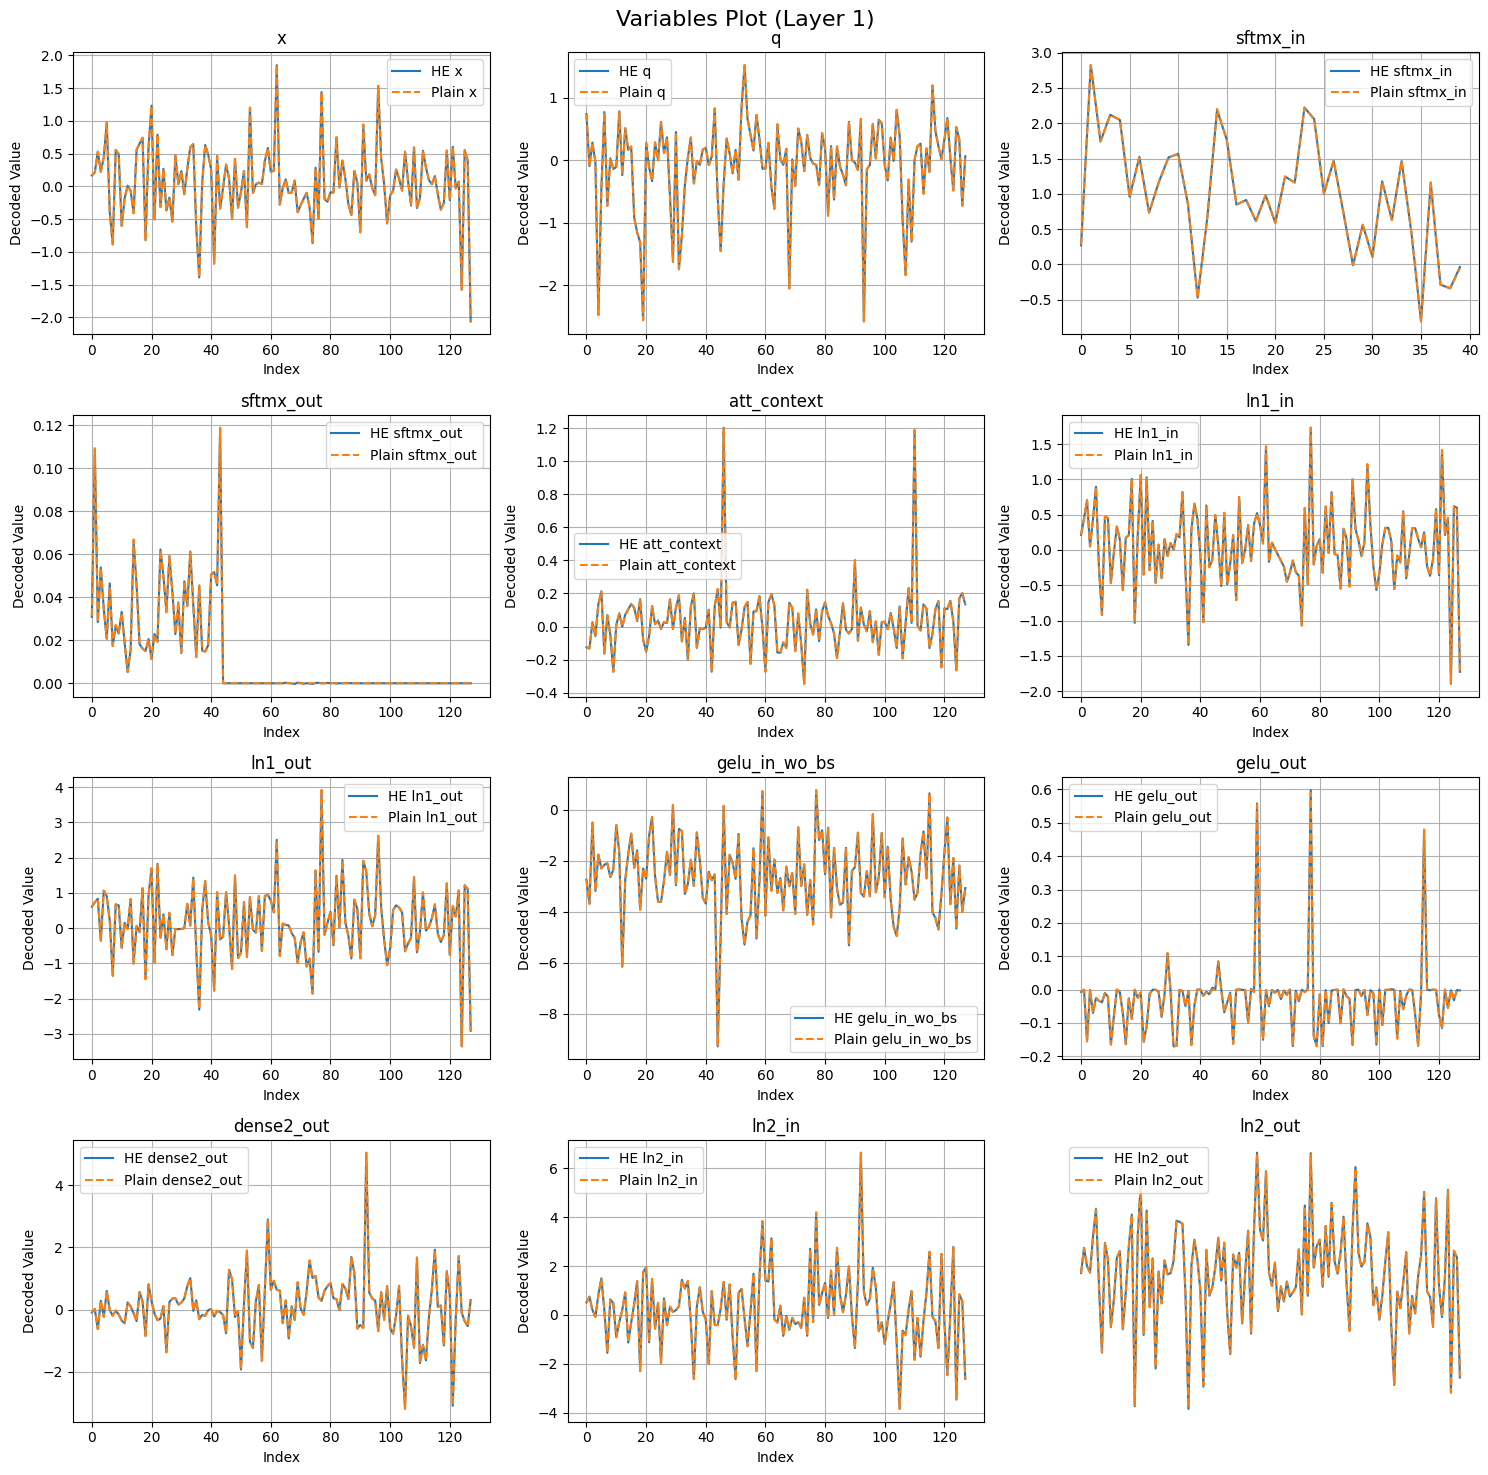

In [ ]:
layer_idx = 0
x1, variables = run_he_layer(x, 0, plot_i=0)

 ### 2-2. Run and Plot Layer 1

layer_idx: 1
[GPU] after releasing ff layer 1: [11286, 58439, 8099, 4] MiB


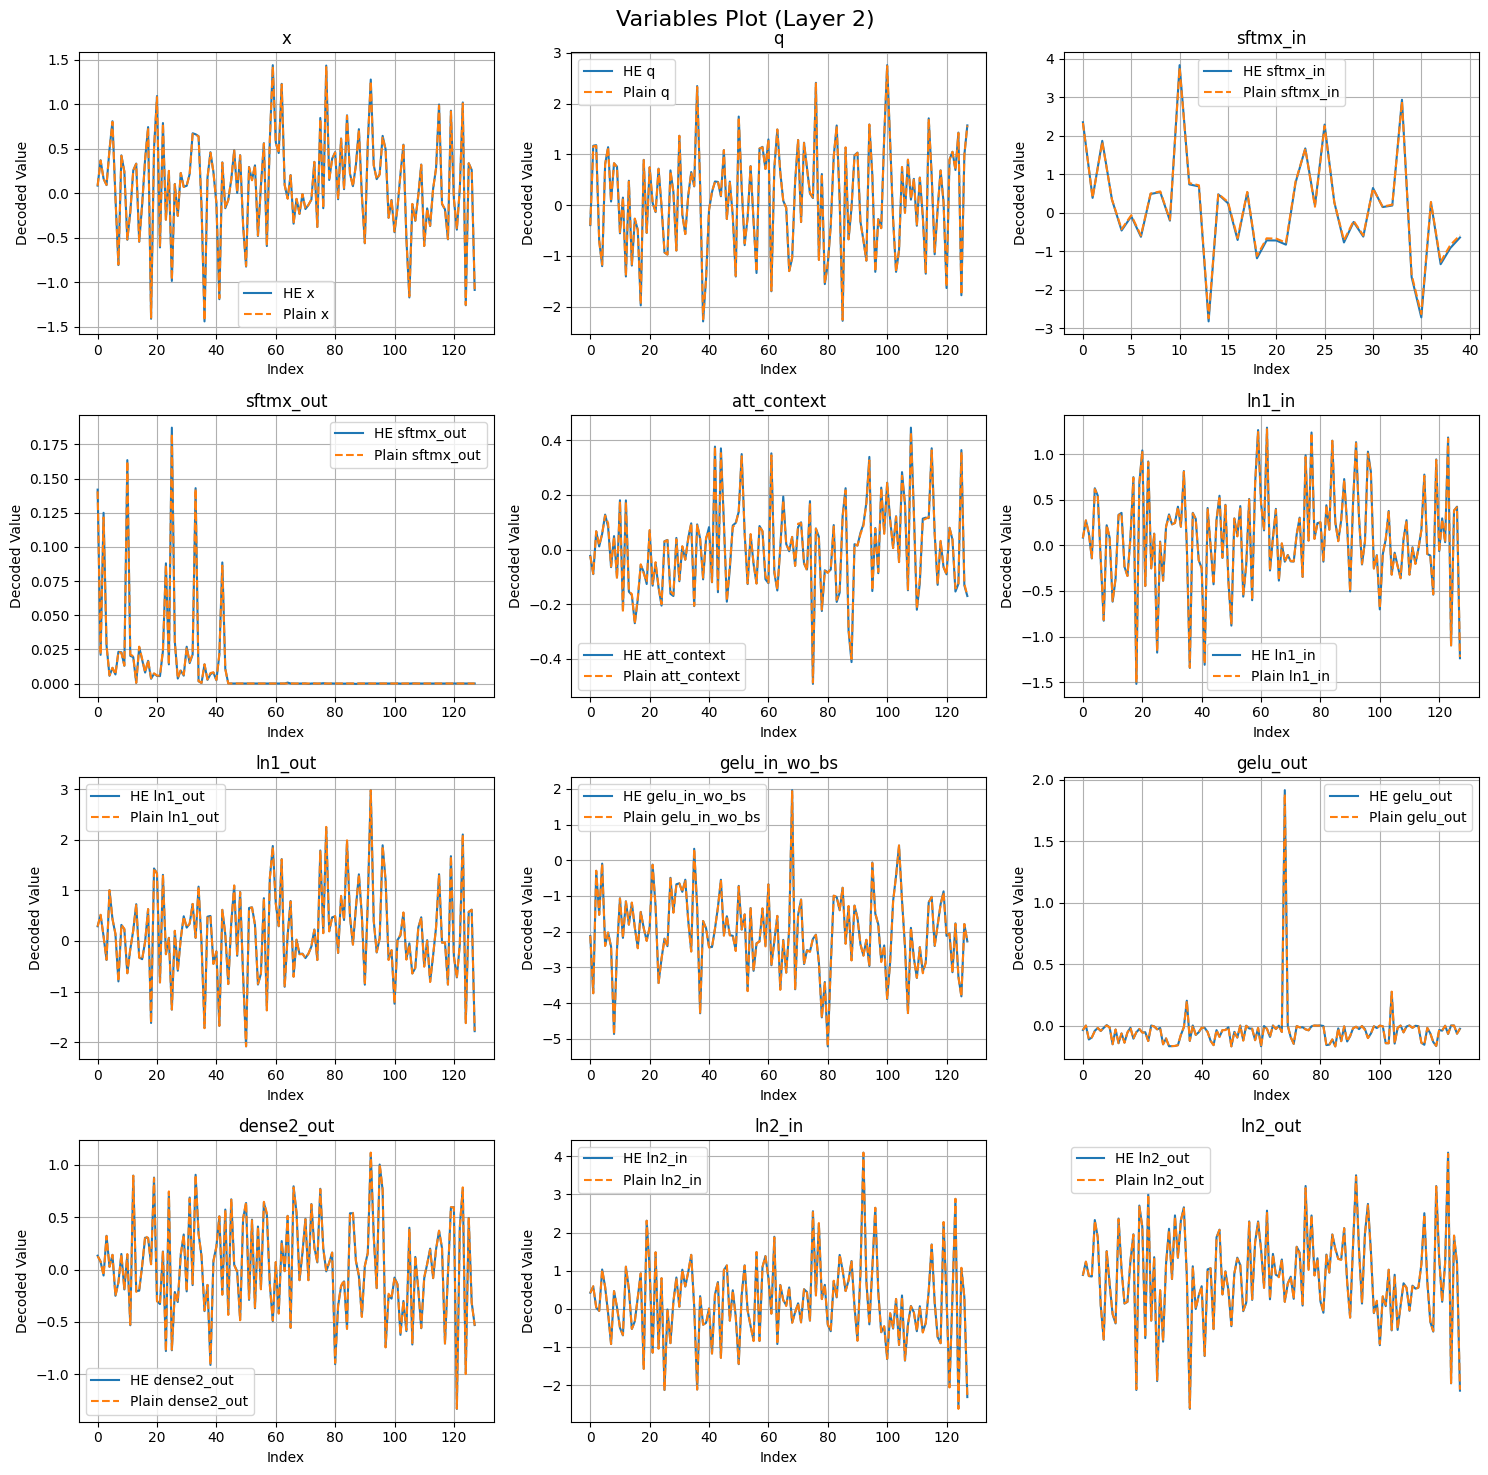

In [ ]:
layer_idx = 1
x2 , variables2 = run_he_layer(x1, 1, plot_i=0)

 ### 2-3. Run and Plot Layer 2

layer_idx: 2
[GPU] after releasing ff layer 2: [11286, 57537, 8099, 4] MiB


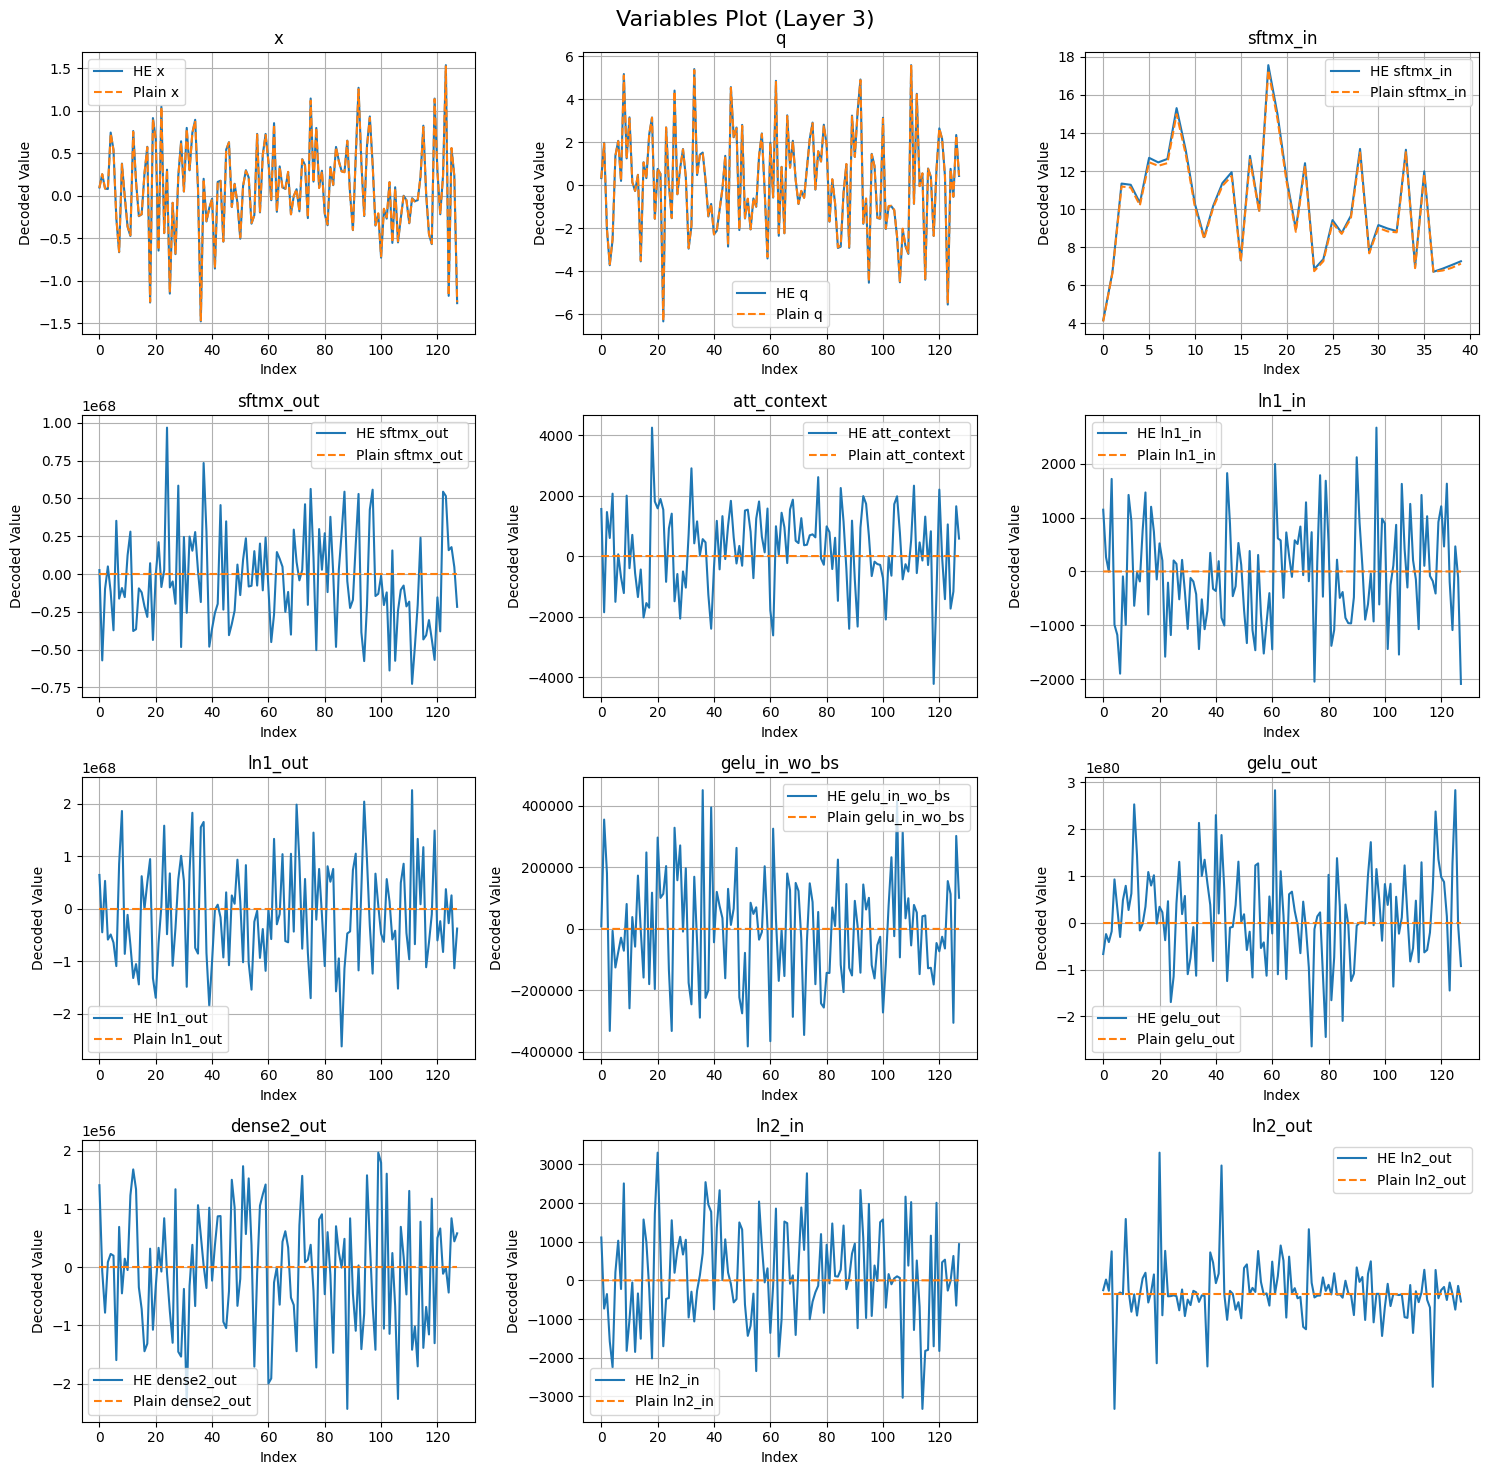

In [ ]:
layer_idx = 2
x3, variables3 = run_he_layer(x2, 2, plot_i=0)

 ### 2-4. Run and Plot Layer 3

layer_idx: 3
[GPU] after releasing ff layer 3: [11286, 56635, 8099, 4] MiB


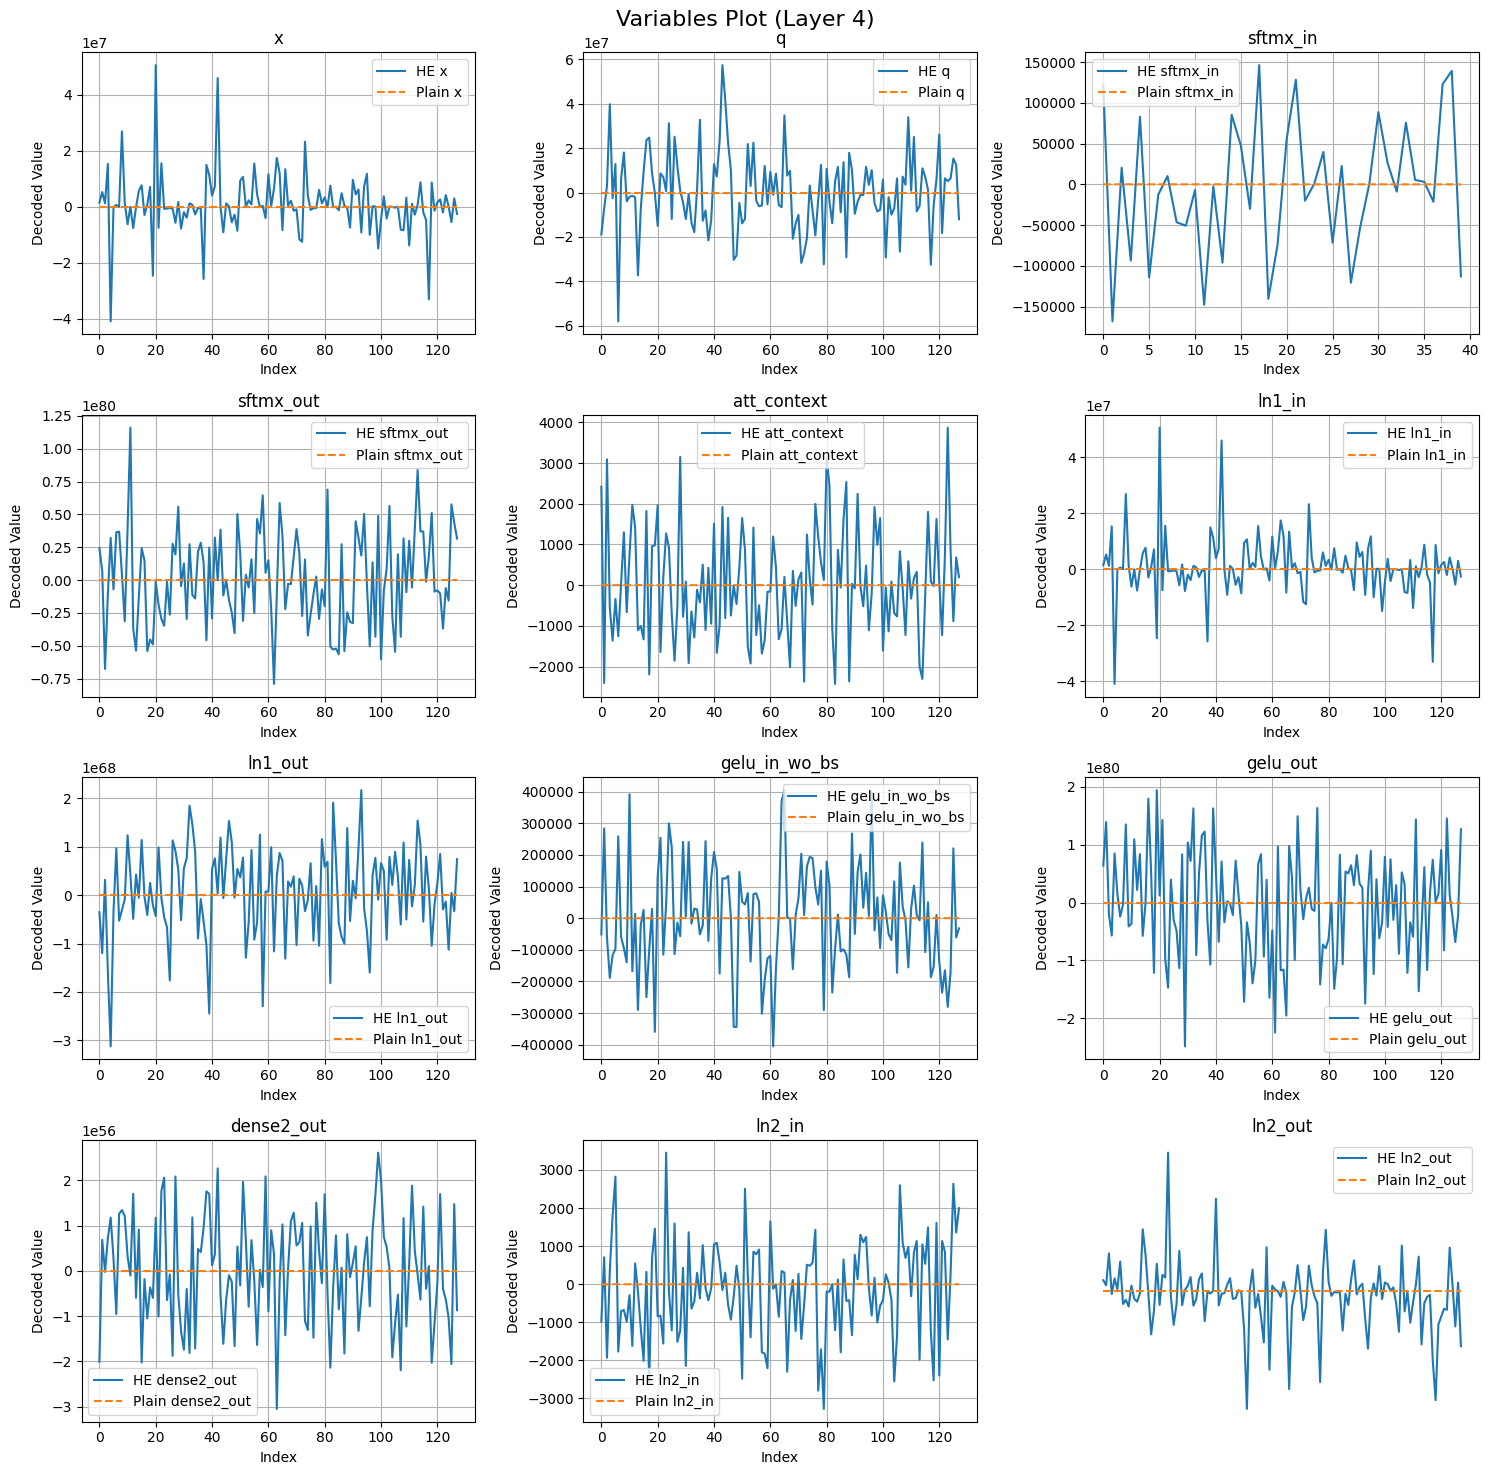

In [ ]:
layer_idx = 3
x4, variables = run_he_layer(x3, 3, plot_i=0)

 ### 2-5. Run and Plot Layer 4

layer_idx: 4
[GPU] after releasing ff layer 4: [11286, 55729, 8099, 4] MiB


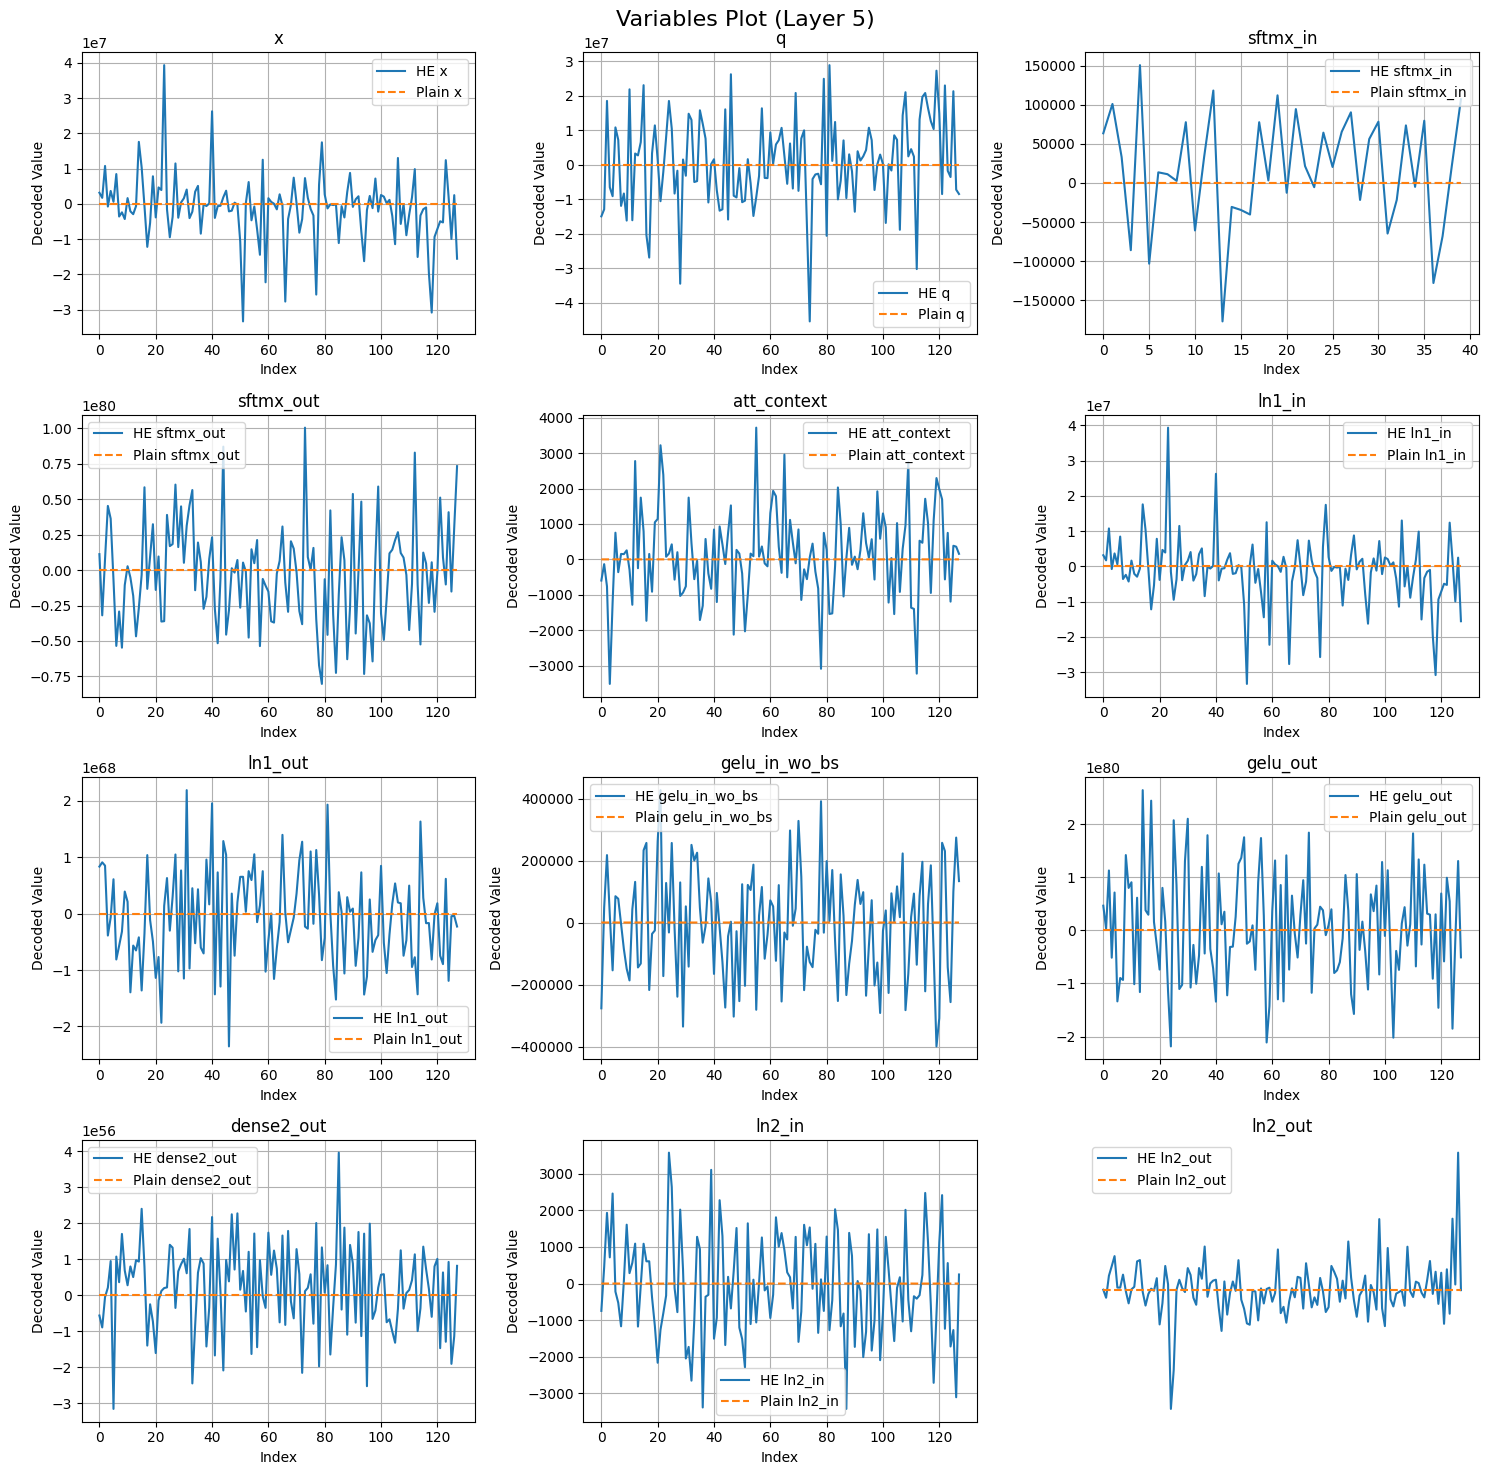

In [ ]:
layer_idx = 4
x5 , variables = run_he_layer(x4, 4)

 ### 2-6. Run and Plot Layer 5

layer_idx: 5
[GPU] after releasing ff layer 5: [11286, 54821, 8099, 4] MiB


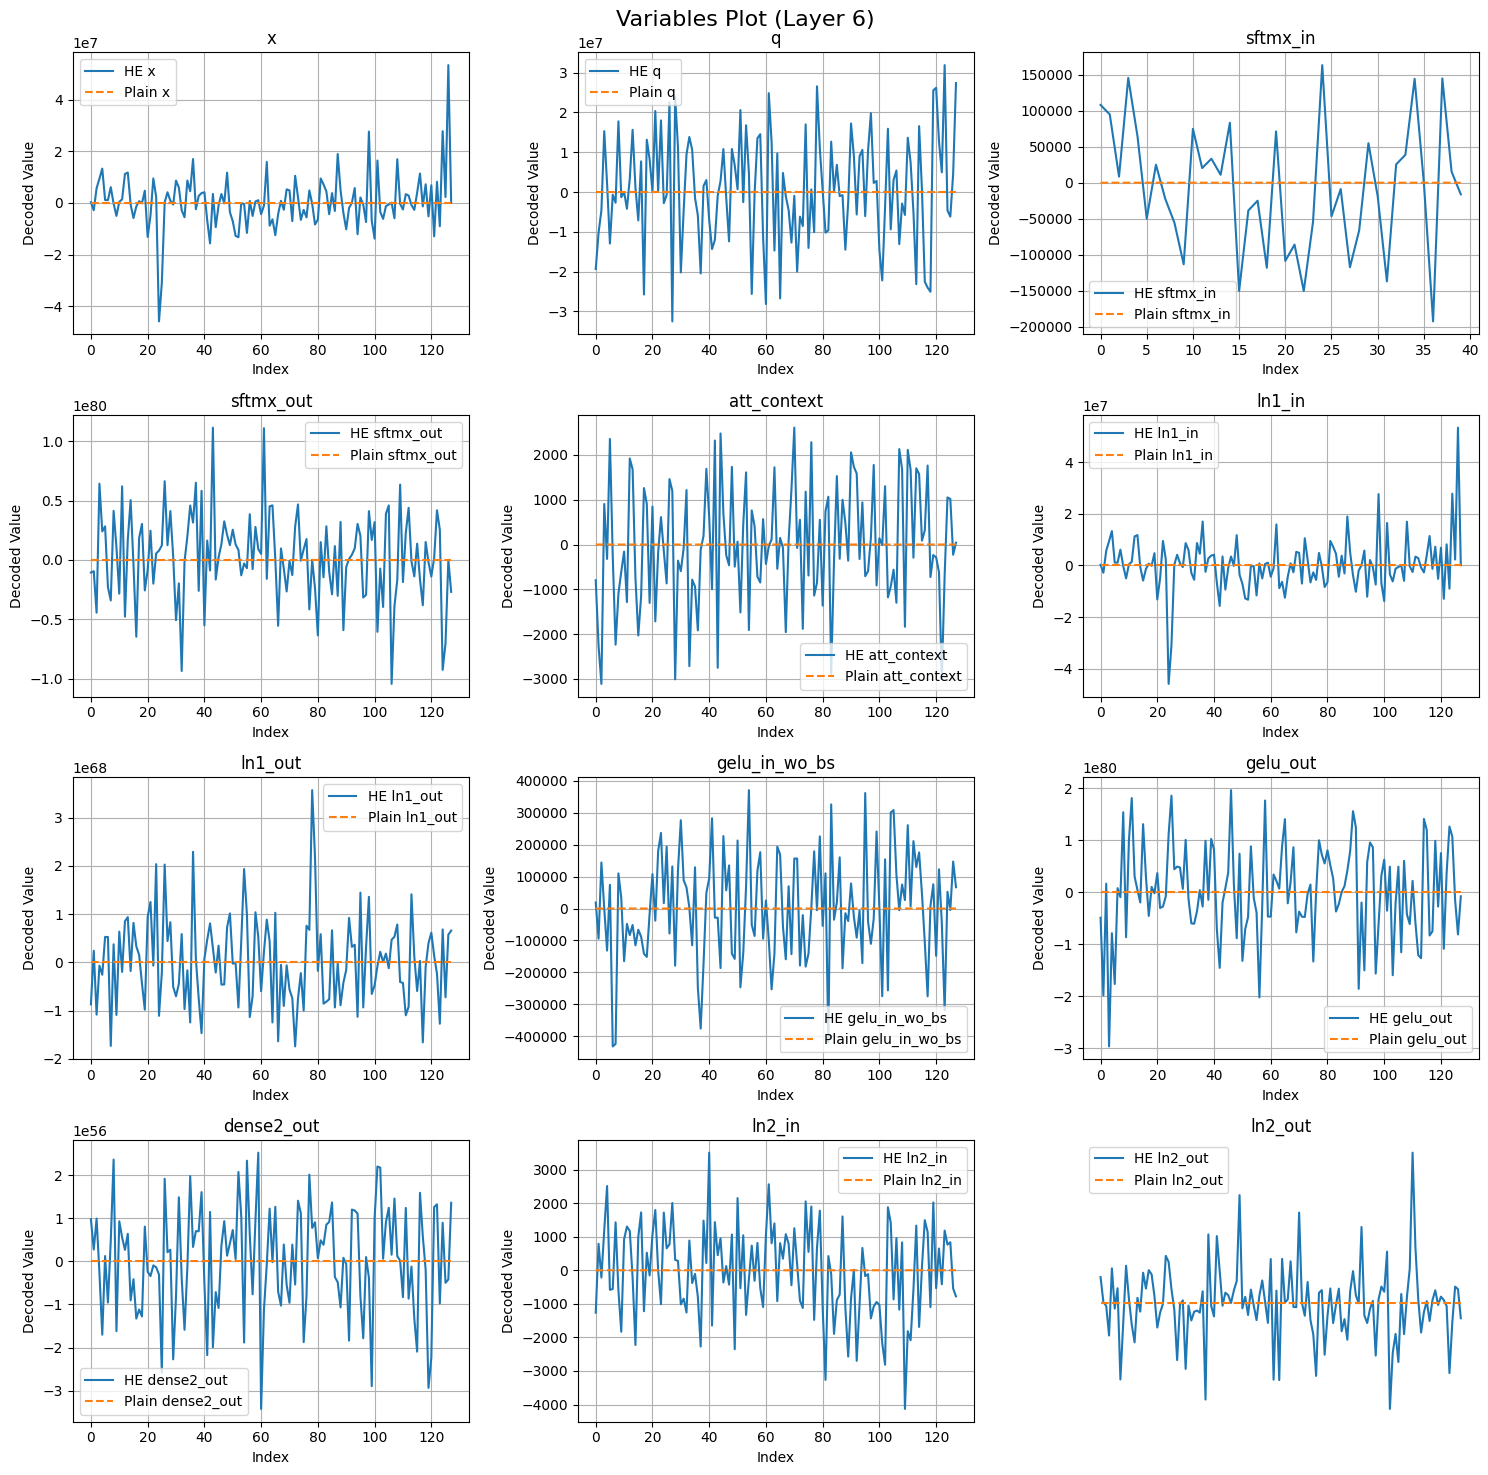

In [ ]:
layer_idx = 5
x6 , variables = run_he_layer(x5, 5)

 ### 2-7. Run and Plot Layer 6

layer_idx: 6
[GPU] after releasing ff layer 6: [11286, 53913, 8099, 4] MiB


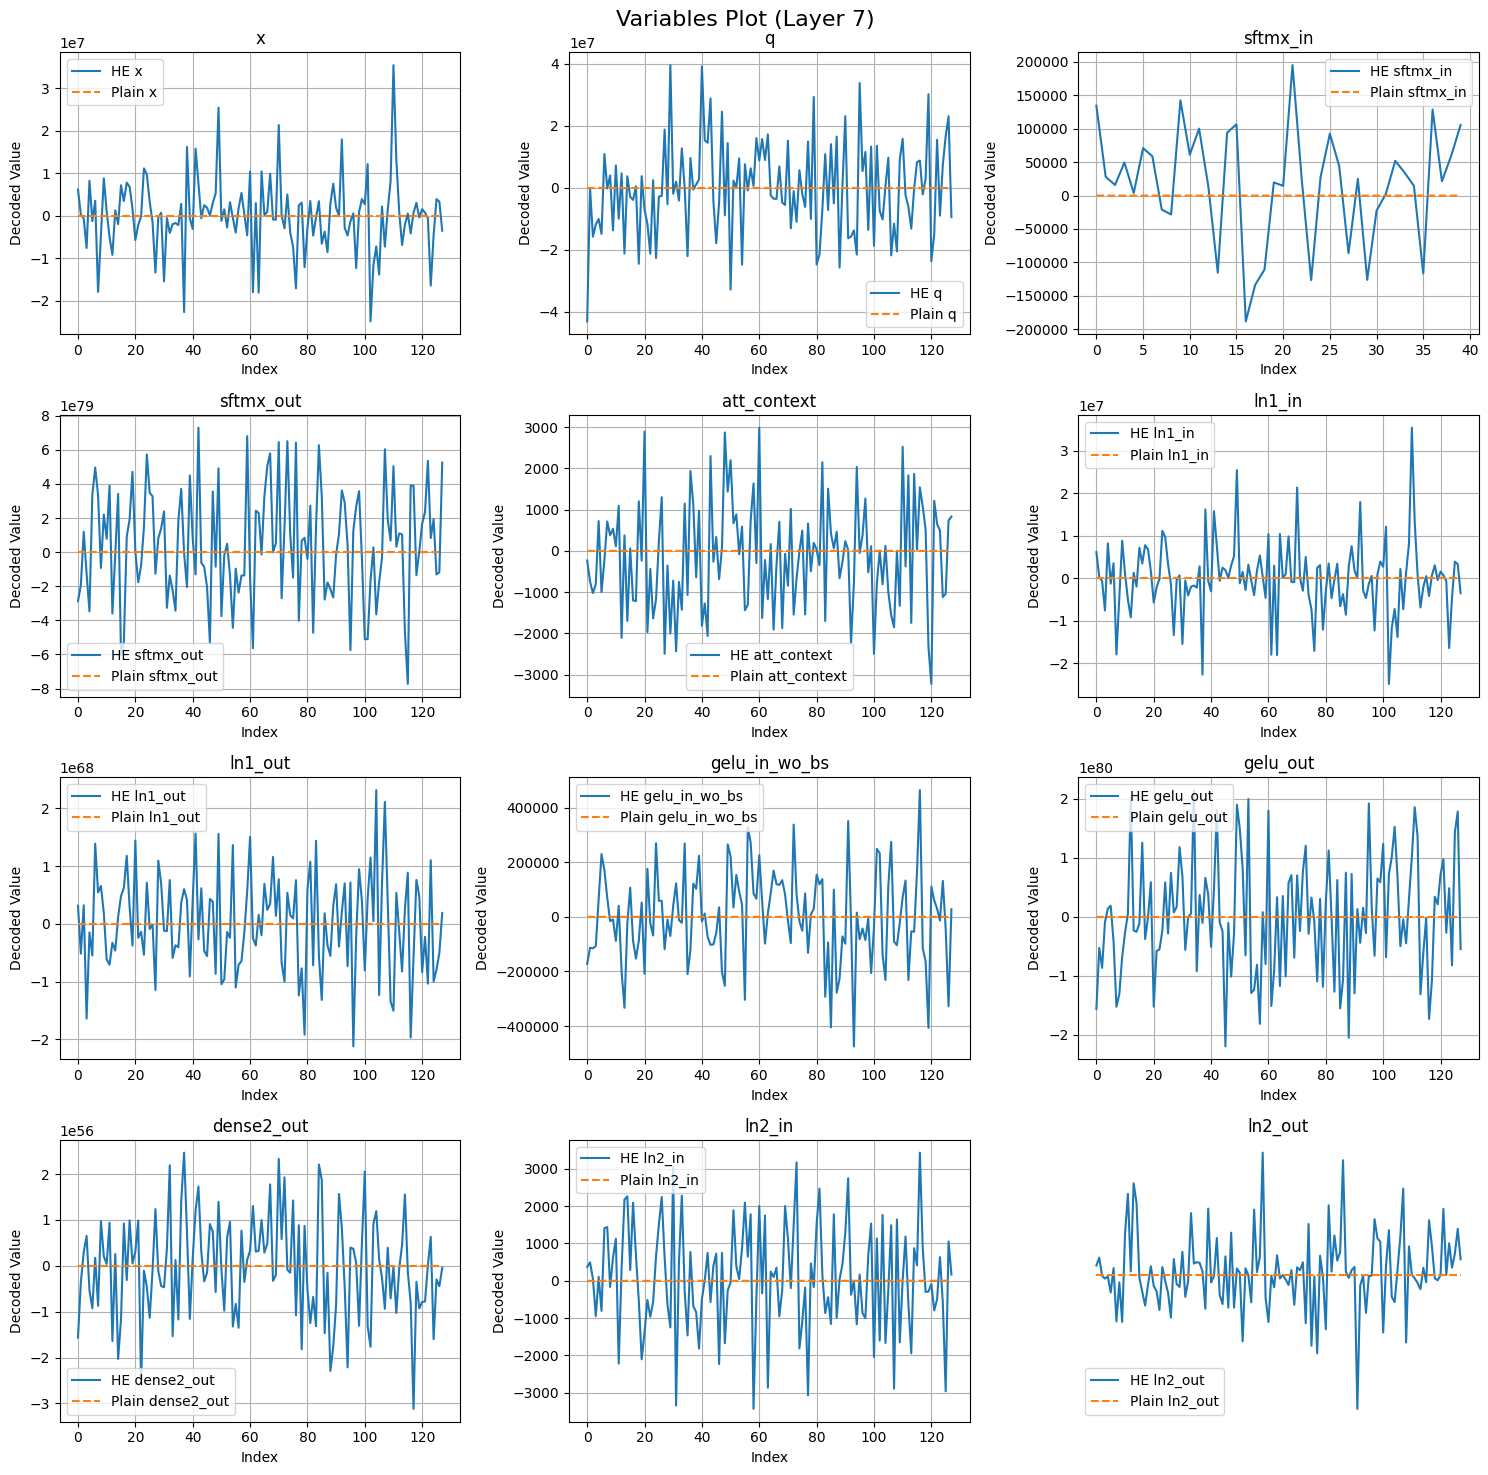

In [ ]:
layer_idx = 6
x7, variables = run_he_layer(x6, 6)

 ### 2-8. Run and Plot Layer 7

layer_idx: 7
[GPU] after releasing ff layer 7: [69700, 53005, 8099, 4] MiB


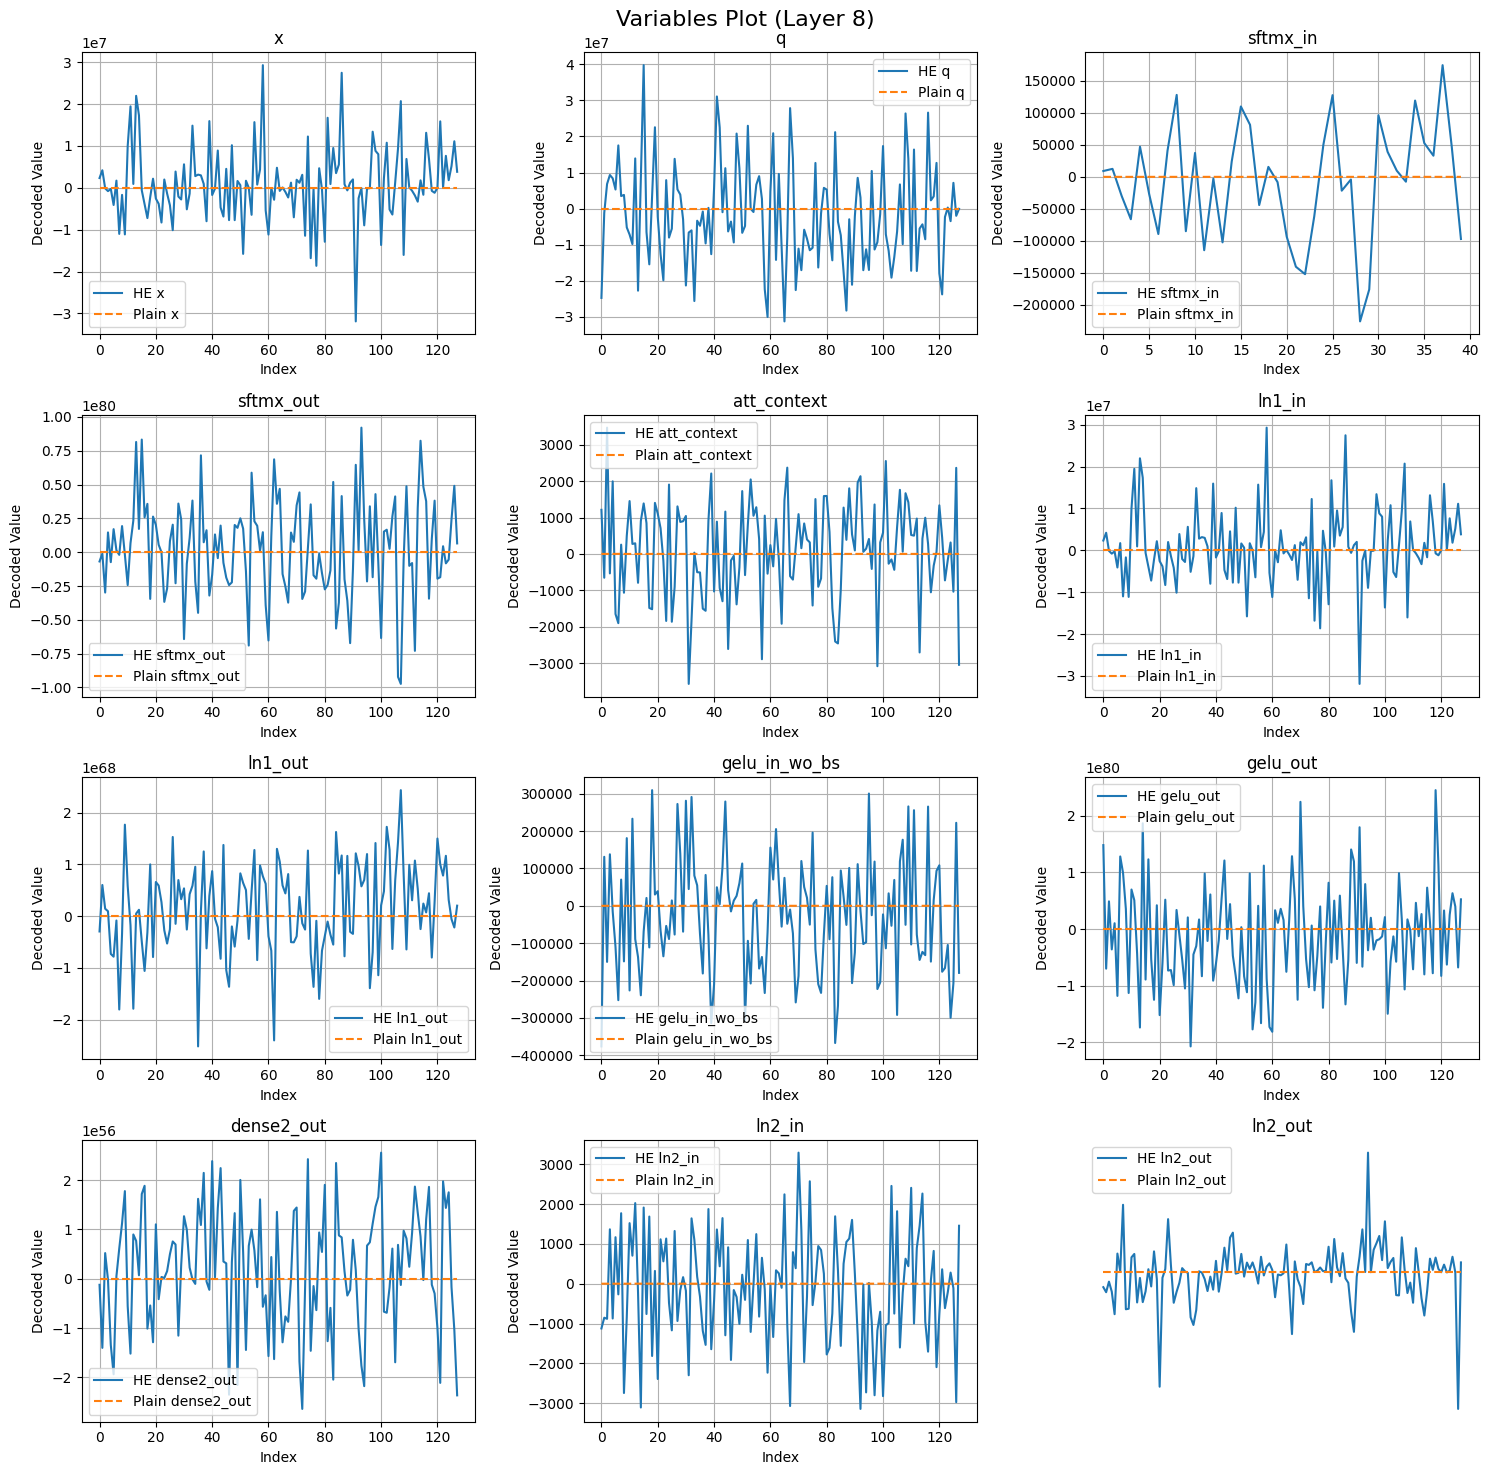

In [ ]:
layer_idx = 7
x8 , variables = run_he_layer(x7, 7)

 ### 2-9. Run and Plot Layer 8

layer_idx: 8
[GPU] after releasing ff layer 8: [69700, 52097, 8099, 4] MiB


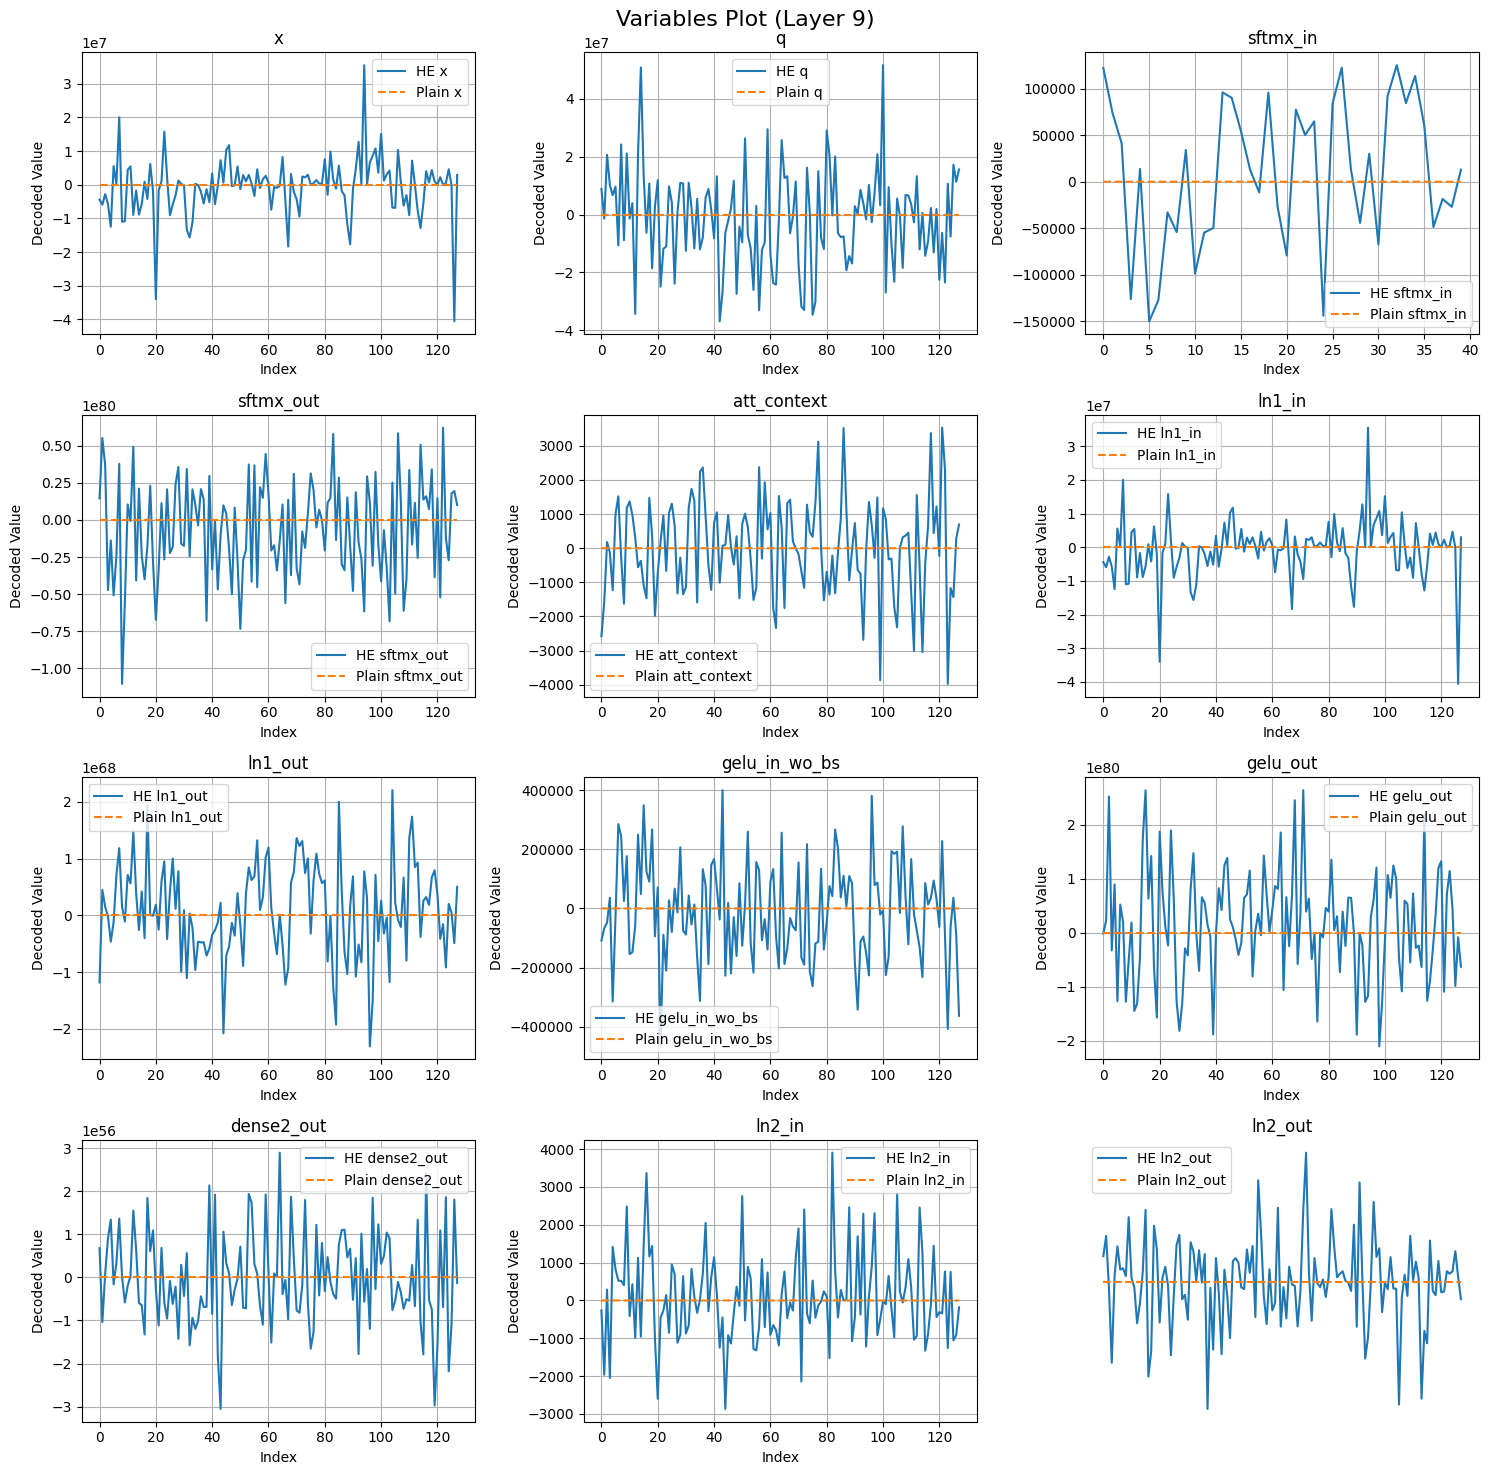

In [ ]:
layer_idx = 8
x9, variables = run_he_layer(x8, 8)

 ### 2-10. Run and Plot Layer 9

layer_idx: 9
[GPU] after releasing ff layer 9: [69700, 51189, 8099, 4] MiB


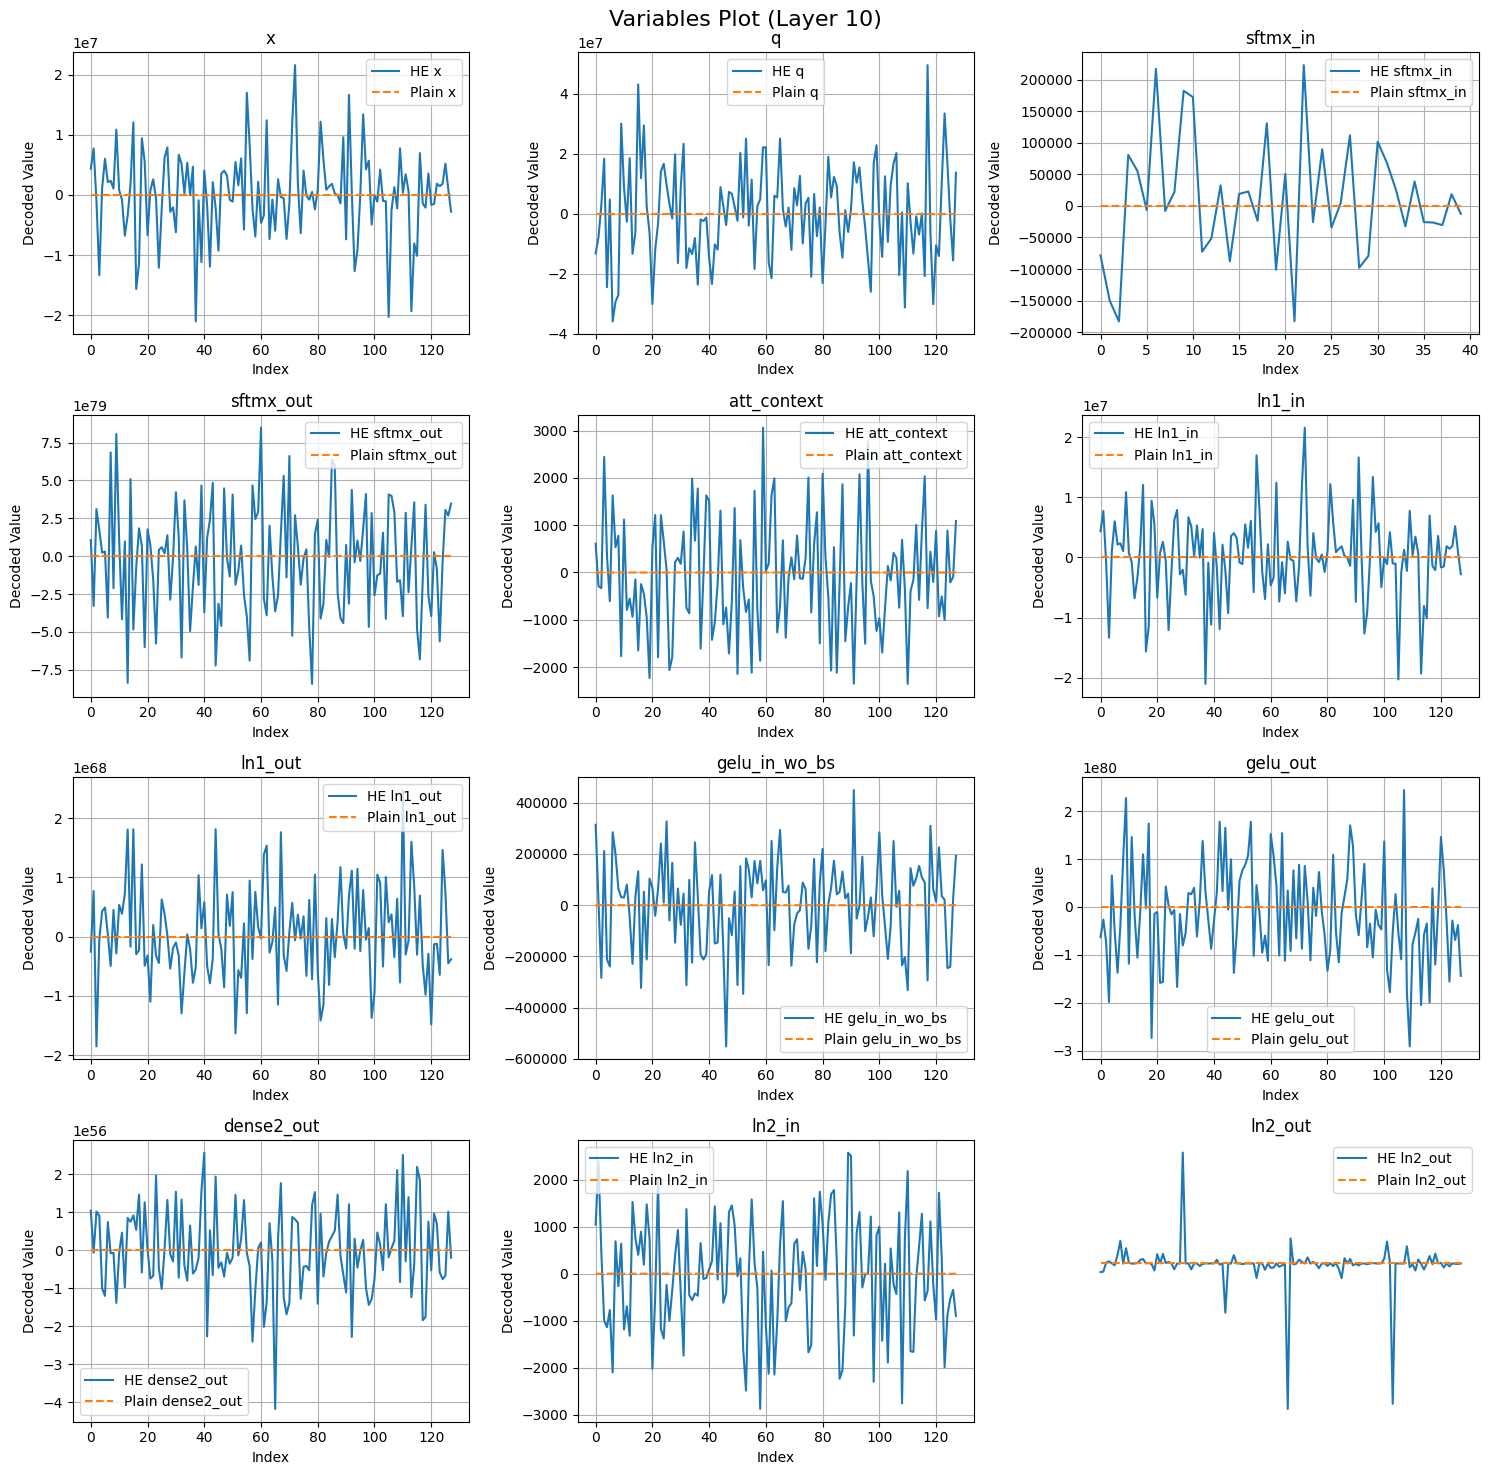

In [ ]:
layer_idx = 9
x10, variables = run_he_layer(x9, 9)

 ### 2-11. Run and Plot Layer 10

layer_idx: 10
[GPU] after releasing ff layer 10: [69700, 50279, 8099, 4] MiB


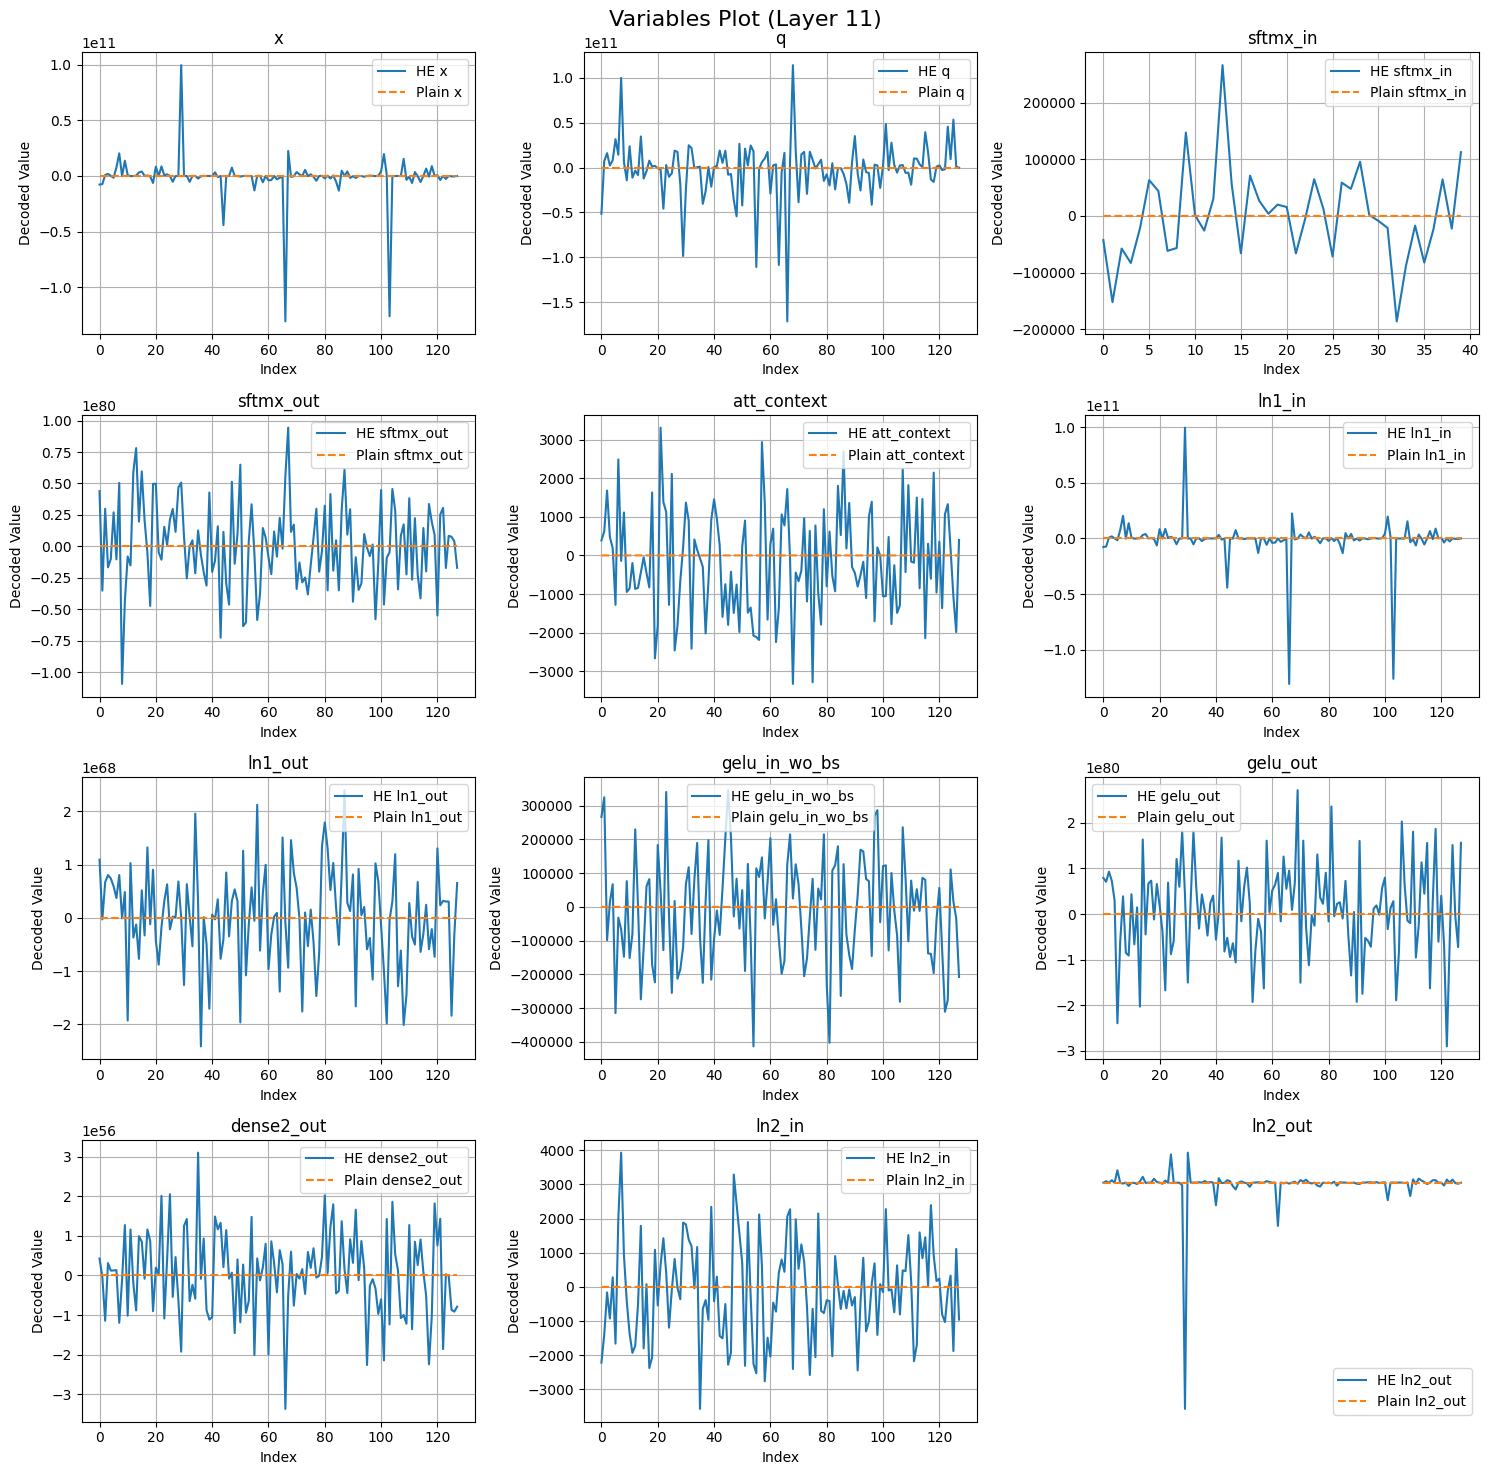

In [ ]:
layer_idx = 10
x11, variables = run_he_layer(x10, 10)

 ### 2-12. Run and Plot Layer 11

layer_idx: 11
[GPU] after releasing ff layer 11: [69700, 49373, 8099, 4] MiB


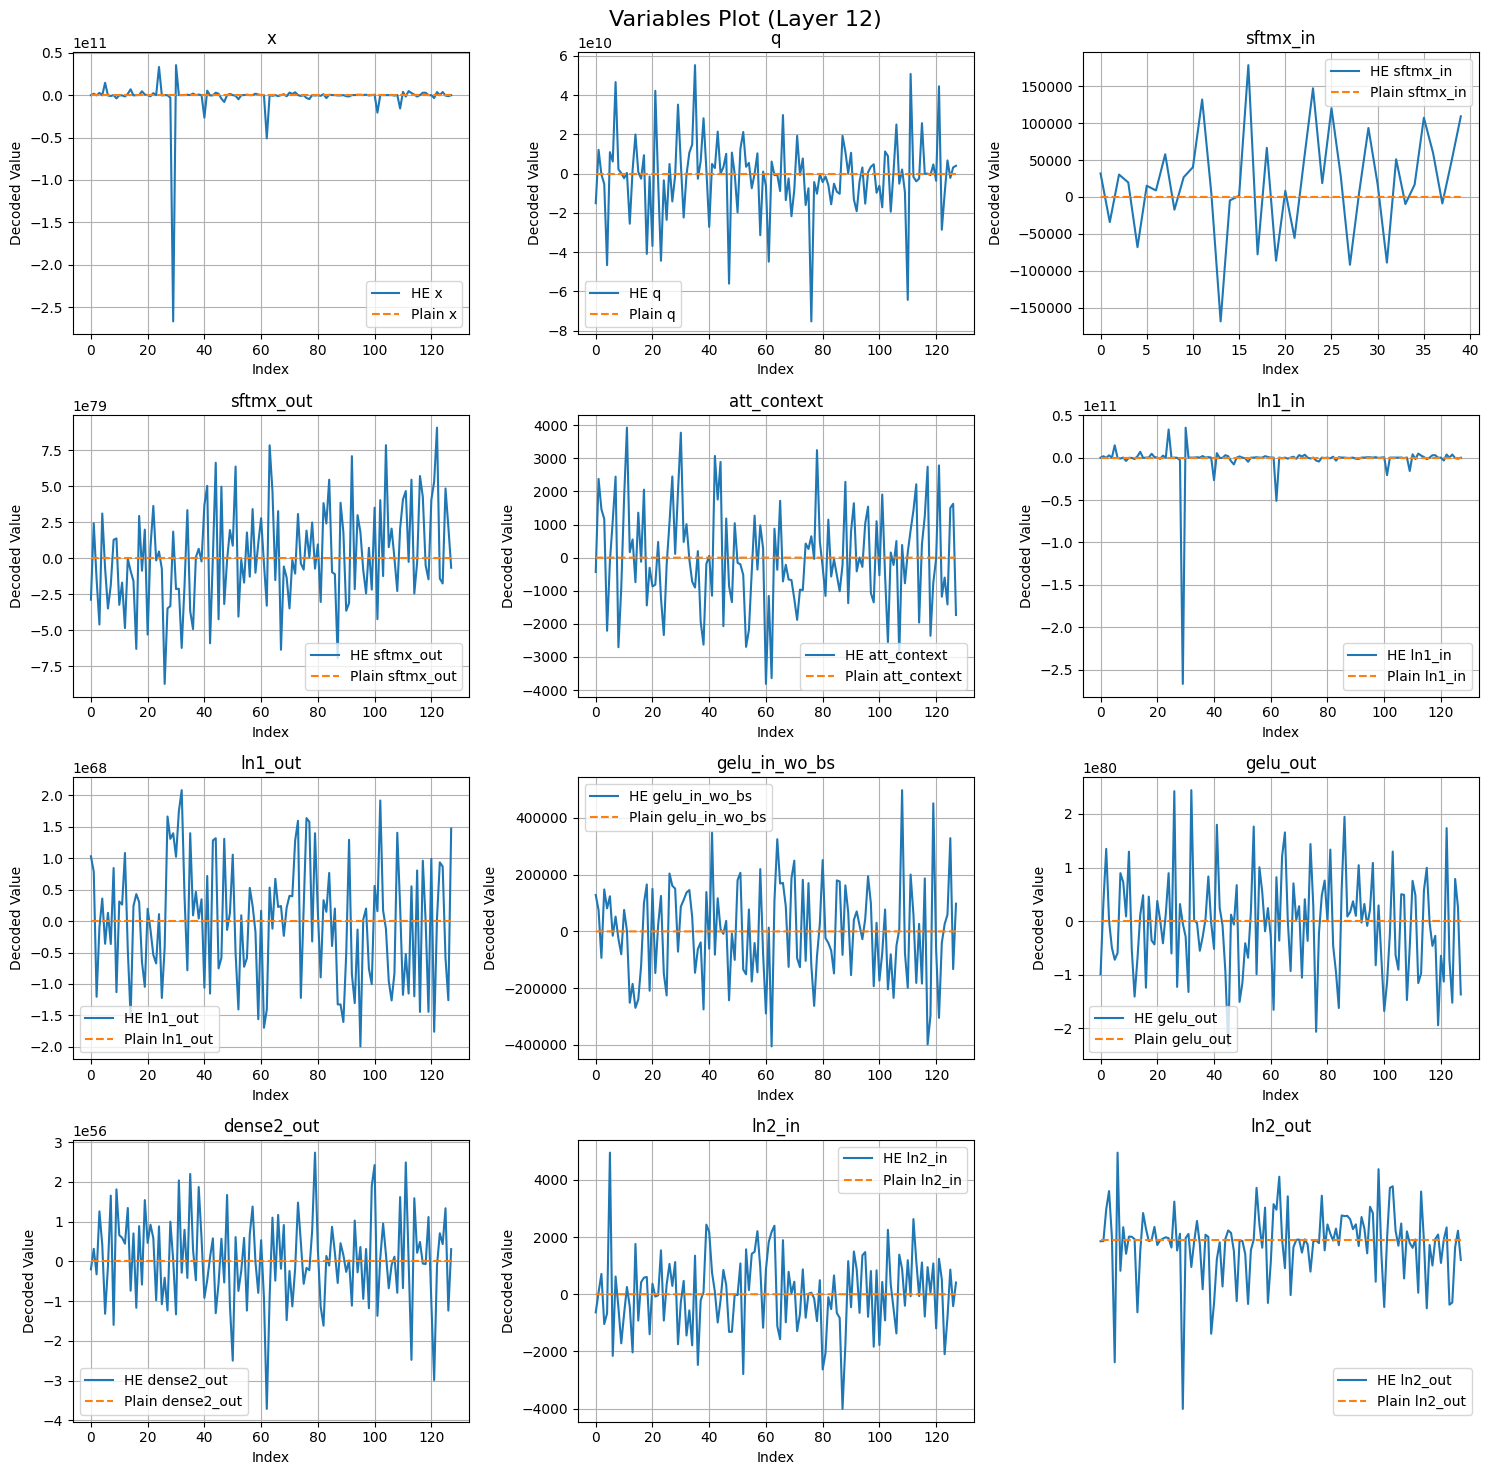

In [ ]:
layer_idx = 11
x12, variables = run_he_layer(x11, 11)

 ## 3. Run Pooler and Classification

 ### 3-1. Run Pooler

In [ ]:
thor_bert.pooler.to(devices)
x = thor_bert.pooler.forward(x12)
print_gpu_memory("after pooler forward")

# Release memory for attention weights and thor_bert

thor_bert.pooler.cpu()
for attention in thor_bert.attentions:
    attention.cpu()
thor_bert.attentions.clear()
for feed_forward in thor_bert.ffs:
    feed_forward.cpu()
thor_bert.ffs.clear()
thor_bert.pooler.weights.clear()
del pooler_weights
del weights_pt
del thor_bert
del model_plain
print_gpu_memory("after releasing 1")

del variables
del variables2
del variables3
del x1, x2, x3, x4, x5, x6, x7, x8, x9, x10, x11, x12
print_gpu_memory("after releasing 2")
variables_list.clear()
del variables_list
del outputs

thor_attention = None
gc.collect()
torch.cuda.empty_cache()
print_gpu_memory("after releasing 3")

[GPU] after pooler forward: [69700, 49345, 8099, 4] MiB
[GPU] after releasing 1: [69700, 49331, 8099, 4] MiB
[GPU] after releasing 2: [69700, 49331, 8099, 4] MiB
[GPU] after releasing 3: [69700, 22999, 8099, 4] MiB


 ### 3-2. Run Classification

In [ ]:
x = run_classifier(x)

[GPU] after encoded classifier weights: [69700, 60111, 8099, 4] MiB
[GPU] after releasing classifier weights: [69700, 23041, 8099, 4] MiB


 ### 4. Comparison between the prediction and the actual label

In [ ]:
import pandas as pd
from datasets import load_dataset

# Load the dataset from the GLUE benchmark
dataset = load_dataset("glue", dataset_type)

# Extract the validation split from the dataset
val_set = dataset["validation"]

# Decrypt the encrypted predictions using the secret key
a = engine.decrypt(x[0], sk)[0]
b = engine.decrypt(x[1], sk)[0]

# Predict 0 if a > b, otherwise predict 1
pred = 0 if a > b else 1

# Retrieve the ground-truth label from the validation set
label = val_set["label"][target_idx]

# Display the prediction and the actual label
print(f"Predicted by HE: {pred}, Ground Truth: {label}")

Predicted by HE: 1, Ground Truth: 1
